# Spatial data processing 

## Make boundary of Europe

Done — saved to data/processed/spatial_data/europe_boundary.gpkg


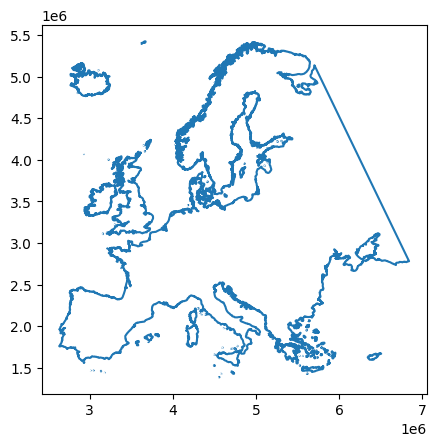

In [6]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import box, MultiPolygon, Polygon

# ── 1. Load Natural Earth 1:10m countries ────────────────────────────────────
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip"
)

# ── 2. European countries — match on ISO_A2, ISO_A3, or NAME ─────────────────
EUROPE_ISO2 = {
    "AL", "AD", "AT", "BY", "BE", "BA", "BG", "HR", "CY", "CZ",
    "DK", "EE", "FI", "FR", "DE", "GR", "HU", "IS", "IE", "IT",
    "LV", "LI", "LT", "LU", "MT", "MD", "MC", "ME", "NL",
    "MK", "PL", "PT", "RO", "RU", "SM", "RS", "SK", "SI",
    "ES", "SE", "CH", "UA", "GB", "VA",
    # Turkey removed
}
EUROPE_ISO3 = {"FRA", "NOR", "XKX"}

EUROPE_NAMES = {"France", "Norway", "Kosovo"}  # name-based fallback

europe = world[
    world["ISO_A2"].isin(EUROPE_ISO2)
    | world["ISO_A3"].isin(EUROPE_ISO3)
    | world["NAME"].isin(EUROPE_NAMES)
].copy()

# ── 3. Clip Russia ────────────────────────────────────────────────────────────
RUSSIA_EAST_MERIDIAN = 42

russia_clip_box = box(-30, 30, RUSSIA_EAST_MERIDIAN, 82)
russia_row = europe[europe["ISO_A2"] == "RU"].copy()
russia_clipped = russia_row.copy()
russia_clipped["geometry"] = russia_row.intersection(russia_clip_box)

europe = europe[europe["ISO_A2"] != "RU"]
europe = gpd.GeoDataFrame(
    pd.concat([europe, russia_clipped], ignore_index=True),
    crs="EPSG:4326"
)

# FIX: use a western bound of -30 to exclude the Pacific-side wrap-around chunk
russia_clip_box = box(-30, 30, RUSSIA_EAST_MERIDIAN, 82)

russia_row = europe[europe["ISO_A2"] == "RU"].copy()
russia_clipped = russia_row.copy()
russia_clipped["geometry"] = russia_row.intersection(russia_clip_box)

europe = europe[europe["ISO_A2"] != "RU"]
europe = gpd.GeoDataFrame(
    pd.concat([europe, russia_clipped], ignore_index=True),
    crs="EPSG:4326"
)

# ── 4. Reproject to LAEA Europe ───────────────────────────────────────────────
europe = europe.to_crs("EPSG:3035")

# ── 5. Dissolve to single polygon ────────────────────────────────────────────
europe_dissolved = europe.dissolve().geometry.iloc[0]

# ── 6. Clip to European longitude/latitude extent BEFORE buffering ────────────
# This removes any overseas territories regardless of size
# Bounds: ~25°W to 50°E, 34°N to 72°N — adjust as needed
EUROPE_BOUNDS_4326 = box(-25, 34, 50, 72)

# We need to clip in WGS84, so work on the pre-reprojected data
# Rebuild: re-dissolve in 4326, clip, then reproject

europe_4326 = europe.to_crs("EPSG:4326")  # europe is still in scope from step 4
europe_dissolved_4326 = europe_4326.dissolve().geometry.iloc[0]
europe_clipped_4326 = europe_dissolved_4326.intersection(EUROPE_BOUNDS_4326)

# Reproject clipped geometry to 3035
europe_clipped_gdf = gpd.GeoDataFrame(
    geometry=[europe_clipped_4326], crs="EPSG:4326"
).to_crs("EPSG:3035")

europe_boundary = europe_clipped_gdf.geometry.iloc[0]

# ── 7. Save ───────────────────────────────────────────────────────────────────
europe_boundary_gdf = gpd.GeoDataFrame(geometry=[europe_boundary], crs="EPSG:3035")
europe_boundary_gdf.to_file("../../data/processed/spatial_data/europe_boundary.gpkg", driver="GPKG")

europe_boundary_gdf.boundary.plot()
print("Done — saved to data/processed/spatial_data/europe_boundary.gpkg")

### Rasterize

In [7]:
"""
Rasterize Europe boundary polygon to a 10 km x 10 km raster.

Input:  data/processed/spatial_data/europe_boundary.gpkg
Output: data/processed/spatial_data/europe_boundary_10km.tif

Assumes the boundary is in EPSG:3035 (ETRS89/LAEA Europe), which uses
metres as units — so 10 km = 10,000 m pixel size.
"""

import numpy as np
import geopandas as gpd
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import rasterize

# ── Config ────────────────────────────────────────────────────────────────────

INPUT_PATH  = "../../data/processed/spatial_data/europe_boundary.gpkg"
OUTPUT_PATH = "../../data/processed/spatial_data/europe_boundary_10km.tif"
PIXEL_SIZE  = 10_000          # 10 km in metres (assumes projected CRS)
NODATA      = 0
BURN_VALUE  = 1               # pixel value inside the boundary

# ── Load boundary ─────────────────────────────────────────────────────────────

gdf = gpd.read_file(INPUT_PATH)
print(f"CRS detected: {gdf.crs}")
print(f"  → If this is not EPSG:3035, reproject before running.")

# Ensure the geometry is in a metre-based CRS so PIXEL_SIZE is meaningful.
# Uncomment the next line if you need to reproject:
# gdf = gdf.to_crs("EPSG:3035")

bounds = gdf.total_bounds          # (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = bounds
print(f"Bounds (m): {minx:.0f}, {miny:.0f}, {maxx:.0f}, {maxy:.0f}")

# ── Compute raster dimensions ─────────────────────────────────────────────────

width  = int(np.ceil((maxx - minx) / PIXEL_SIZE))
height = int(np.ceil((maxy - miny) / PIXEL_SIZE))
print(f"Raster size: {width} cols × {height} rows  ({width * height / 1e6:.2f} M pixels)")

# Affine transform: top-left corner, positive x / negative y
transform = from_bounds(minx, miny, maxx, maxy, width, height)

# ── Rasterize ─────────────────────────────────────────────────────────────────

shapes = ((geom, BURN_VALUE) for geom in gdf.geometry if geom is not None)

raster = rasterize(
    shapes,
    out_shape=(height, width),
    transform=transform,
    fill=NODATA,
    dtype="uint8",
    all_touched=False,   # True = include pixels touched by boundary edge
)

# ── Write GeoTIFF ─────────────────────────────────────────────────────────────

profile = {
    "driver":    "GTiff",
    "dtype":     "uint8",
    "width":     width,
    "height":    height,
    "count":     1,
    "crs":       gdf.crs,
    "transform": transform,
    "nodata":    NODATA,
    "compress":  "lzw",   # lossless, keeps file small
    "tiled":     True,
    "blockxsize": 256,
    "blockysize": 256,
}

with rasterio.open(OUTPUT_PATH, "w", **profile) as dst:
    dst.write(raster, 1)

print(f"\nDone — saved to {OUTPUT_PATH}")
print(f"  Pixels inside boundary : {raster.sum():,}")
print(f"  Total pixels           : {raster.size:,}")

CRS detected: EPSG:3035
  → If this is not EPSG:3035, reproject before running.
Bounds (m): 2635415, 1385618, 6840057, 5424004
Raster size: 421 cols × 404 rows  (0.17 M pixels)

Done — saved to ../../data/processed/spatial_data/europe_boundary_10km.tif
  Pixels inside boundary : 73,208
  Total pixels           : 170,084


### Plot raster

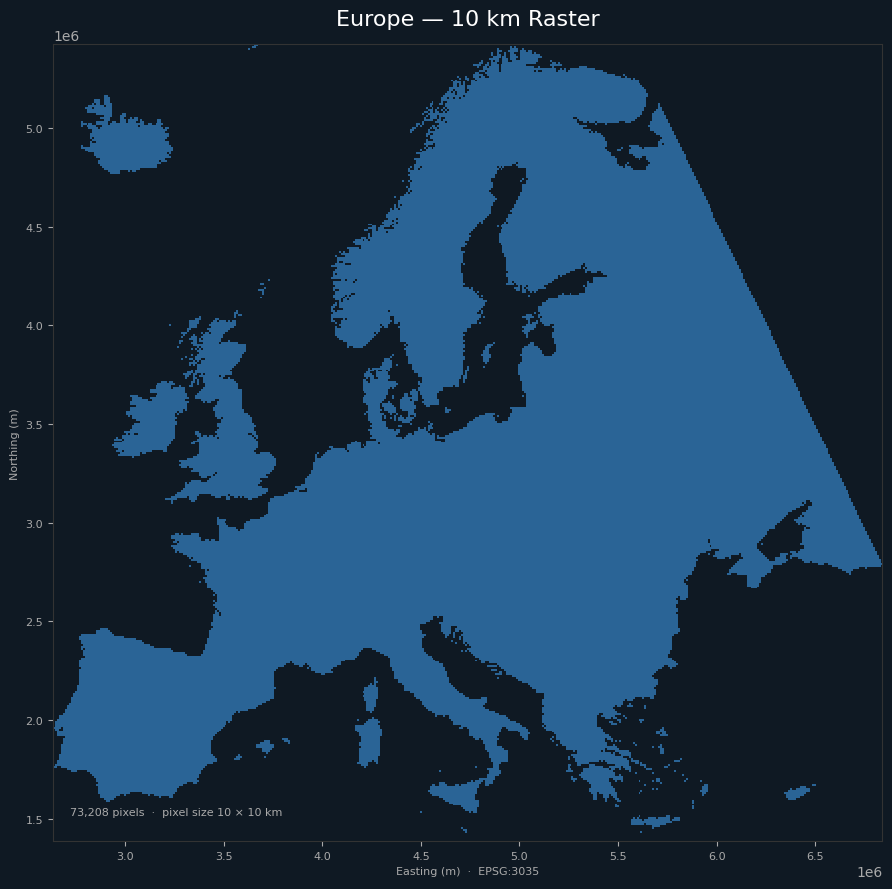

In [8]:
"""
Visualize the Europe boundary raster (europe_boundary_10km.tif).
"""

import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

INPUT_PATH = "../../data/processed/spatial_data/europe_boundary_10km.tif"

# ── Load raster ───────────────────────────────────────────────────────────────

with rasterio.open(INPUT_PATH) as src:
    data      = src.read(1).astype(float)
    bounds    = src.bounds
    crs       = src.crs
    nodata    = src.nodata

# Mask nodata / background pixels
if nodata is not None:
    data = np.where(data == nodata, np.nan, data)

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 9), facecolor="#0f1923")
ax.set_facecolor("#0f1923")

# Extent for correct axis labels (in CRS units, metres)
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Land: solid colour; background: transparent (NaN → transparent via cmap)
cmap = mcolors.ListedColormap(["#2a6496"])   # single colour for value=1
cmap.set_bad(color="#0f1923")                # NaN = background colour

ax.imshow(
    data,
    extent=extent,
    origin="upper",
    cmap=cmap,
    interpolation="nearest",
    vmin=0.5, vmax=1.5,
)

# ── Formatting ────────────────────────────────────────────────────────────────

ax.set_title("Europe — 10 km Raster", color="white", fontsize=16, pad=14)
ax.set_xlabel(f"Easting (m)  ·  {crs}", color="#aaaaaa", fontsize=8)
ax.set_ylabel("Northing (m)", color="#aaaaaa", fontsize=8)

ax.tick_params(colors="#aaaaaa", labelsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor("#333333")

# Pixel-count annotation
n_land = int(np.nansum(data))
ax.text(
    0.02, 0.03,
    f"{n_land:,} pixels  ·  pixel size 10 × 10 km",
    transform=ax.transAxes,
    color="#aaaaaa", fontsize=8,
    va="bottom",
)

plt.tight_layout()
plt.show()

## Agricultural data - SPAM

### SPAM - crop area (hectares)

In [14]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from pathlib import Path

# ── Load boundary in WGS84 to match SPAM's CRS ───────────────────────────────
boundary = gpd.read_file("../../data/processed/spatial_data/europe_boundary.gpkg").to_crs("EPSG:4326")

# ── File paths ────────────────────────────────────────────────────────────────
data_dir = Path("../../data/raw_data/spatial_data/crops_SPAM")
out_dir  = Path("../../data/processed/spatial_data/crops_SPAM")
out_dir.mkdir(parents=True, exist_ok=True)

crops = ["COTT", "OFIB", "OPUL"]

# ── Crop each file ────────────────────────────────────────────────────────────
for crop in crops:
    in_path  = data_dir / f"spam2020_V2r2_global_A_{crop}_A.tif"
    out_path = out_dir  / f"spam2020_V2r2_europe_{crop}.tif"

    with rasterio.open(in_path) as src:
        out_image, out_transform = mask(
            src, boundary.geometry, crop=True, nodata=src.nodata
        )
        out_meta = src.meta.copy()
        out_meta.update({
            "height":    out_image.shape[1],
            "width":     out_image.shape[2],
            "transform": out_transform,
        })
        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(out_image)

    print(f"Saved: {out_path}")

Saved: ../../data/processed/spatial_data/crops_SPAM/spam2020_V2r2_europe_COTT.tif
Saved: ../../data/processed/spatial_data/crops_SPAM/spam2020_V2r2_europe_OFIB.tif
Saved: ../../data/processed/spatial_data/crops_SPAM/spam2020_V2r2_europe_OPUL.tif


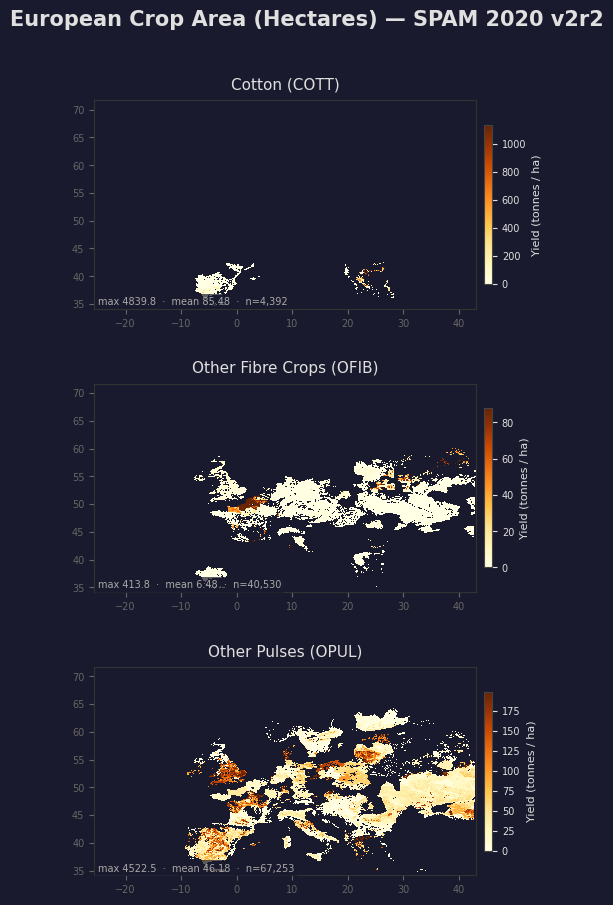

In [20]:
"""
Visualize three crop yield GeoTIFFs side by side.

Crops:
  COTT  — Cotton
  OFIB  — Other fibre crops
  OPUL  — Other pulses
"""

import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter

# ── Config ────────────────────────────────────────────────────────────────────

FILES = {
    "Cotton (COTT)":           "../../data/processed/spatial_data/crops/spam2020_V2r2_europe_COTT.tif",
    "Other Fibre Crops (OFIB)":"../../data/processed/spatial_data/crops/spam2020_V2r2_europe_OFIB.tif",
    "Other Pulses (OPUL)":     "../../data/processed/spatial_data/crops/spam2020_V2r2_europe_OPUL.tif",
}

CMAP      = "YlOrBr"   # perceptually uniform, good for yield data
BG_COLOR  = "#1a1a2e"
TEXT_COLOR = "#e0e0e0"

# ── Load rasters ──────────────────────────────────────────────────────────────

datasets = {}
for label, path in FILES.items():
    with rasterio.open(path) as src:
        data   = src.read(1).astype(float)
        nodata = src.nodata
        bounds = src.bounds
        crs    = src.crs

    # Mask nodata and zero/negative values
    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)
    data = np.where(data <= 0, np.nan, data)

    datasets[label] = {"data": data, "bounds": bounds, "crs": crs}

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(5, 9), facecolor=BG_COLOR)
fig.suptitle(
    "European Crop Area (Hectares) — SPAM 2020 v2r2",
    color=TEXT_COLOR, fontsize=15, fontweight="bold", y=1.01
)

for ax, (label, ds) in zip(axes, datasets.items()):
    data   = ds["data"]
    bounds = ds["bounds"]
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    # Consistent colour scale per crop (0 → max), ignoring outliers
    vmax = np.nanpercentile(data, 98)   # clip top 2% so outliers don't wash out the map

    cmap = plt.get_cmap(CMAP).copy()
    cmap.set_bad(color=BG_COLOR)        # NaN → background

    im = ax.imshow(
        data,
        extent=extent,
        origin="upper",
        cmap=cmap,
        interpolation="nearest",
        vmin=0,
        vmax=vmax,
    )

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02, orientation="vertical")
    cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR, labelcolor=TEXT_COLOR, labelsize=7)
    cbar.outline.set_edgecolor("#444444")
    cbar.set_label("Yield (tonnes / ha)", color=TEXT_COLOR, fontsize=8)

    # Stats annotation
    valid = data[~np.isnan(data)]
    stats = (
        f"max {np.nanmax(data):.1f}  ·  "
        f"mean {np.nanmean(data):.2f}  ·  "
        f"n={len(valid):,}"
    )
    ax.text(
        0.01, 0.01, stats,
        transform=ax.transAxes,
        color="#aaaaaa", fontsize=7, va="bottom",
        bbox=dict(facecolor=BG_COLOR, edgecolor="none", alpha=0.7, pad=2),
    )

    ax.set_title(label, color=TEXT_COLOR, fontsize=11, pad=8)
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors="#666666", labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

### Eurostat - yield (tonnes per hectare)

In [27]:
"""
Preprocess Eurostat crop yield data (2024) and join to a Europe shapefile.

Steps:
  1. Download Europe country boundaries from Natural Earth (free, no account needed)
  2. Parse the three Eurostat Excel files, extracting 2024 yield values
  3. Join yield data to the shapefile by country name
  4. Save as a GeoPackage with three yield columns

Output: data/processed/spatial_data/europe_crop_yields_2024.gpkg

Dependencies: geopandas, pandas, openpyxl, requests
  pip install geopandas pandas openpyxl requests
"""

import io
import zipfile
import requests
import numpy as np
import pandas as pd
import geopandas as gpd

# ── Config ────────────────────────────────────────────────────────────────────

# Adjust paths to your Excel files
FILES = {
    "yield_cotton_t_ha":    "../../data/raw_data/spatial_data/crops_eurostat/cottonFiber_yield_nationalData_tonnesPerHectare.xlsx",
    "yield_hemp_t_ha":      "../../data/raw_data/spatial_data/crops_eurostat/hemp_yield_nationalData_tonnesPerHectare.xlsx",
    "yield_peas_t_ha":      "../../data/raw_data/spatial_data/crops_eurostat/peas_yield_nationalData_tonnesPerHectare.xlsx",
}

# Sheet 1 = peas/hemp; Sheet 3 = cotton (inside the peas file)
SHEET_MAP = {
    "yield_cotton_t_ha":  {"file": FILES["yield_cotton_t_ha"], "sheet": "Sheet 3"},
    "yield_hemp_t_ha":    {"file": FILES["yield_hemp_t_ha"],   "sheet": "Sheet 1"},
    "yield_peas_t_ha":    {"file": FILES["yield_peas_t_ha"],   "sheet": "Sheet 1"},
}

OUTPUT_PATH = "../../data/processed/spatial_data/crops/eurostat_crop_yields_2024.gpkg"
YEAR = "2024"

# ── 1. Download Europe shapefile (Natural Earth 1:10m cultural vectors) ───────

print("Downloading Europe country boundaries from Natural Earth …")
NE_URL = (
    "https://naciscdn.org/naturalearth/10m/cultural/"
    "ne_10m_admin_0_countries.zip"
)
resp = requests.get(NE_URL, timeout=60)
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    z.extractall("ne_countries_10m")

world = gpd.read_file("ne_countries_10m/ne_10m_admin_0_countries.shp")

# Filter to Europe (sovereign states + dependent territories on the continent)
europe = world[world["CONTINENT"] == "Europe"].copy()
print(f"  → {len(europe)} European features loaded")

# ── 2. Parse Eurostat Excel files ─────────────────────────────────────────────

def parse_eurostat_sheet(filepath, sheet_name, col_name, year=YEAR):
    """
    Read a Eurostat crop yield sheet and return a tidy DataFrame with
    columns [country, <col_name>].

    Eurostat quirks handled:
      - Header rows before the data table (skip until 'GEO' row)
      - Flag codes after values (e.g. '1.5 e', '3.2 p') — strip them
      - Missing / suppressed values marked ':' → NaN
      - EU aggregate rows — dropped
    """
    raw = pd.read_excel(filepath, sheet_name=sheet_name, header=None, dtype=str)

    # Find the row where the GEO column label appears
    geo_row = None
    for i, row in raw.iterrows():
        if any(str(c).strip().startswith("GEO") for c in row):
            geo_row = i
            break
    if geo_row is None:
        raise ValueError(f"Could not find GEO header row in {filepath} / {sheet_name}")

    # The TIME header row is one above GEO
    time_row = geo_row - 1
    years    = raw.iloc[time_row].tolist()

    # Find which column corresponds to `year`
    year_cols = [j for j, v in enumerate(years) if str(v).strip() == str(year)]
    if not year_cols:
        raise ValueError(f"Year {year} not found in {filepath} / {sheet_name}")
    year_col = year_cols[0]

    # Data starts from geo_row + 1 (skip the "GEO (Labels)" label row itself)
    data = raw.iloc[geo_row + 1:].copy()
    data.columns = range(len(data.columns))

    # Column 0 = country name, year_col = value (may be followed by a flag col)
    df = data[[0, year_col]].copy()
    df.columns = ["country", "raw_value"]

    # Drop EU aggregate rows (long names containing "European Union")
    df = df[~df["country"].str.contains("European Union", na=True)]
    df = df[df["country"].notna() & (df["country"].str.strip() != "")]

    # Clean value: strip flag letters, convert ':' to NaN
    def clean_val(v):
        v = str(v).strip()
        if v in (":", "nan", ""):
            return np.nan
        # Remove trailing flag codes (single letters like e, p, b, u)
        parts = v.split()
        try:
            return float(parts[0])
        except ValueError:
            return np.nan

    df[col_name] = df["raw_value"].apply(clean_val)
    df = df[["country", col_name]].copy()
    df["country"] = df["country"].str.strip()
    return df

print(f"\nParsing Eurostat data for {YEAR} …")
df_cotton = parse_eurostat_sheet(
    FILES["yield_cotton_t_ha"], "Sheet 3", "yield_cotton_t_ha"
)
df_hemp   = parse_eurostat_sheet(
    FILES["yield_hemp_t_ha"],   "Sheet 1", "yield_hemp_t_ha"
)
df_peas   = parse_eurostat_sheet(
    FILES["yield_peas_t_ha"],   "Sheet 1", "yield_peas_t_ha"
)

# Merge all three on country
yields = (
    df_peas
    .merge(df_hemp,   on="country", how="outer")
    .merge(df_cotton, on="country", how="outer")
)
print(f"  → {len(yields)} country rows after merging")
print(yields.to_string(index=False))

# ── 3. Country name harmonisation ─────────────────────────────────────────────

# Eurostat uses full English names; Natural Earth uses slightly different ones.
NAME_MAP = {
    "Czechia":                  "Czechia",
    "Germany":                  "Germany",
    "Greece":                   "Greece",
    "Bosnia and Herzegovina":   "Bosnia and Herz.",
    "North Macedonia":          "North Macedonia",
    "Kosovo*":                  "Kosovo",
    "Türkiye":                  "Turkey",
}

yields["ne_name"] = yields["country"].replace(NAME_MAP)

# Natural Earth name column is NAME_LONG or SOVEREIGNT — use NAME for matching
europe["ne_name"] = europe["NAME"]

# ── 4. Spatial join ───────────────────────────────────────────────────────────

result = europe.merge(
    yields[["ne_name", "yield_peas_t_ha", "yield_hemp_t_ha", "yield_cotton_t_ha"]],
    on="ne_name",
    how="left",
)

matched = result[result["yield_peas_t_ha"].notna() |
                 result["yield_hemp_t_ha"].notna() |
                 result["yield_cotton_t_ha"].notna()]
print(f"\nCountries with at least one yield value: {len(matched)}")

unmatched_eurostat = set(yields["ne_name"]) - set(europe["ne_name"])
if unmatched_eurostat:
    print(f"  ⚠ Eurostat countries not matched to shapefile: {unmatched_eurostat}")
    print("    → Check NAME_MAP above and add missing entries.")

# ── 5. Save ───────────────────────────────────────────────────────────────────

# Keep only useful columns
keep_cols = ["NAME", "ISO_A2", "ISO_A3", "SOVEREIGNT",
             "yield_peas_t_ha", "yield_hemp_t_ha", "yield_cotton_t_ha", "geometry"]
keep_cols = [c for c in keep_cols if c in result.columns]
result = result[keep_cols]

result.to_file(OUTPUT_PATH, driver="GPKG", layer="europe_crop_yields_2024")
print(f"\nDone — saved to {OUTPUT_PATH}")
print(f"  Columns: {[c for c in result.columns if c != 'geometry']}")
print(f"  CRS: {result.crs}")

  → 51 European features loaded

Parsing Eurostat data for 2024 …


/Users/tsuitpy/miniconda3/envs/geo_env/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


  → 45 country rows after merging
               country  yield_peas_t_ha  yield_hemp_t_ha  yield_cotton_t_ha
                     :              NaN              NaN                NaN
               Albania              NaN              NaN                NaN
               Austria             2.04             3.91                NaN
               Belgium             2.87              NaN                NaN
Bosnia and Herzegovina             3.09              NaN                NaN
              Bulgaria             1.68              NaN               0.71
               Croatia             1.86              NaN                NaN
                Cyprus             2.16              NaN                NaN
               Czechia             1.67             0.90                NaN
               Denmark             2.97              NaN                NaN
               Estonia             2.37              NaN                NaN
               Finland             2.76              N

In [28]:
result.sort_values("NAME", ascending=True)

,NAME,ISO_A2,ISO_A3,SOVEREIGNT,yield_peas_t_ha,yield_hemp_t_ha,yield_cotton_t_ha,geometry
15,Albania,AL,ALB,Albania,NaN,NaN,NaN,"POLYGON ((20.56715 41.87318, 20.54172 41.86158..."
37,Andorra,AD,AND,Andorra,NaN,NaN,NaN,"POLYGON ((1.70701 42.50278, 1.6975 42.49446, 1..."
26,Austria,AT,AUT,Austria,2.04,3.91,NaN,"POLYGON ((16.94504 48.60417, 16.95434 48.5574,..."
2,Belarus,BY,BLR,Belarus,NaN,NaN,NaN,"POLYGON ((23.60624 51.5174, 23.60231 51.53078,..."
13,Belgium,BE,BEL,Belgium,2.87,NaN,NaN,"POLYGON ((2.5218 51.08754, 2.542 51.09687, 2.5..."
39,Bosnia and Herz.,BA,BIH,Bosnia and Herzegovina,3.09,NaN,NaN,"POLYGON ((17.65333 42.89094, 17.65284 42.89118..."
34,Bulgaria,BG,BGR,Bulgaria,1.68,NaN,0.71,"POLYGON ((26.33336 41.71304, 26.29491 41.71032..."
32,Croatia,HR,HRV,Croatia,1.86,NaN,NaN,"MULTIPOLYGON (((16.5153 46.50171, 16.52109 46...."
5,Czechia,CZ,CZE,Czechia,1.67,0.90,NaN,"POLYGON ((14.81039 50.85845, 14.83168 50.85798..."
18,Denmark,DK,DNK,Denmark,2.97,NaN,NaN,"MULTIPOLYGON (((8.66078 54.89631, 8.66879 54.9..."


### Yield raster maps (tonnes per year (per pixel))
Combining SPAM and Eurostat data 

In [23]:
"""
Compute total crop yield per pixel by combining:
  - SPAM rasters: crop AREA per pixel (hectares)
  - Eurostat GeoPackage: national yield (tonnes per hectare) per country polygon

Then reproject and snap the output to match a reference Europe 10km raster grid.

Method:
  1. Reproject Eurostat polygons to match SPAM raster CRS
  2. Rasterize the yield column → a yield-per-country raster at SPAM resolution
  3. Multiply pixel area (ha) × national yield (t/ha) → total yield (tonnes) per pixel
  4. Reproject/resample output to match the Europe 10km reference grid exactly
  5. Save output GeoTIFFs aligned to the reference grid

Note: SPAM data is 2020; Eurostat yields are 2024. Results reflect 2024 yield
rates applied to 2020 crop area distributions.

Outputs (one per crop, aligned to europe_boundary_10km.tif):
  spam2020_V2r2_europe_COTT_yield_tonnes_10km.tif
  spam2020_V2r2_europe_OFIB_yield_tonnes_10km.tif
  spam2020_V2r2_europe_OPUL_yield_tonnes_10km.tif
"""

import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling
import warnings

# ── Config ────────────────────────────────────────────────────────────────────

GPKG_PATH  = "../../data/processed/spatial_data/crops/eurostat_crop_yields_2024.gpkg"
SPAM_DIR   = "../../data/processed/spatial_data/crops"
OUT_DIR    = "../../data/processed/yield_maps"
REF_PATH   = "../../data/processed/spatial_data/europe_boundary_10km.tif"

CROPS = {
    "COTT": "yield_cotton_t_ha",
    "OFIB": "yield_hemp_t_ha",
    "OPUL": "yield_peas_t_ha",
}

# ── Load reference grid metadata ──────────────────────────────────────────────

print("Loading reference grid …")
with rasterio.open(REF_PATH) as ref:
    ref_crs       = ref.crs
    ref_transform = ref.transform
    ref_width     = ref.width
    ref_height    = ref.height
    ref_nodata    = ref.nodata if ref.nodata is not None else -9999.0

print(f"  CRS:       {ref_crs}")
print(f"  Size:      {ref_width} × {ref_height} px")
print(f"  Transform: {ref_transform}\n")

# ── Load Eurostat polygons ────────────────────────────────────────────────────

print("Loading Eurostat country yield polygons …")
euro = gpd.read_file(GPKG_PATH)
print(f"  {len(euro)} features, CRS: {euro.crs}")
print(f"  Columns: {list(euro.columns)}\n")

# ── Process each crop ─────────────────────────────────────────────────────────

for crop_code, yield_col in CROPS.items():
    name_dict = {
        "COTT": "cotton",
        "OFIB": "hempdust",    
        "OPUL": "peas",
    }
    crop_name = name_dict[crop_code]
    spam_path = f"{SPAM_DIR}/spam2020_V2r2_europe_{crop_code}.tif"
    out_path  = f"{OUT_DIR}/yield_tonnes_perYear_10km_{crop_name}.tif"

    print(f"── {crop_code}  (yield column: {yield_col}) ──────────────────────")

    if yield_col not in euro.columns:
        print(f"  ⚠ Column '{yield_col}' not found in GeoPackage — skipping.")
        print(f"     Available columns: {[c for c in euro.columns if c != 'geometry']}\n")
        continue

    # ── 1. Open SPAM raster ───────────────────────────────────────────────────
    with rasterio.open(spam_path) as src:
        spam_data   = src.read(1).astype(np.float32)
        spam_crs    = src.crs
        spam_transform = src.transform
        width       = src.width
        height      = src.height
        spam_nodata = src.nodata

    if spam_nodata is not None:
        spam_data = np.where(spam_data == spam_nodata, np.nan, spam_data)
    spam_data = np.where(spam_data < 0, np.nan, spam_data)

    valid_pixels = int(np.sum(~np.isnan(spam_data)))
    print(f"  SPAM:     {width}×{height} px | {valid_pixels:,} valid pixels | CRS: {spam_crs}")

    # ── 2. Reproject Eurostat polygons to SPAM CRS ────────────────────────────
    euro_reproj = euro.to_crs(spam_crs)
    euro_valid  = euro_reproj[euro_reproj[yield_col].notna()].copy()
    print(f"  Eurostat: {len(euro_valid)} countries with data for {yield_col}")

    if len(euro_valid) == 0:
        warnings.warn(f"  ⚠ No yield data for {crop_code} — skipping.\n")
        continue

    # ── 3. Rasterize national yield values onto SPAM grid ────────────────────
    shapes = (
        (geom, float(val))
        for geom, val in zip(euro_valid.geometry, euro_valid[yield_col])
        if geom is not None and not np.isnan(float(val))
    )

    yield_raster = rasterize(
        shapes,
        out_shape=(height, width),
        transform=spam_transform,
        fill=np.nan,
        dtype=np.float32,
        all_touched=False,
    )

    covered = int(np.sum(~np.isnan(yield_raster)))
    print(f"  Yield raster: {covered:,} pixels covered by Eurostat polygons")

    # ── 4. Multiply: area (ha) × yield (t/ha) = total yield (tonnes) ─────────
    total_yield  = spam_data * yield_raster
    valid_output = int(np.sum(~np.isnan(total_yield) & (total_yield > 0)))
    total_tonnes = float(np.nansum(total_yield))
    print(f"  Output:   {valid_output:,} pixels with yield > 0")
    print(f"  Total {crop_code} yield (2024 rates × 2020 area): {total_tonnes:,.1f} tonnes")

    # ── 4b. For hemp: convert stalk yield to dust (5% of stalk weight) ───────
    if crop_code == "OFIB":
        total_yield = total_yield * 0.05
        print(f"  Hemp dust (5% of stalk): {float(np.nansum(total_yield)):,.1f} tonnes")

    # ── 5. Reproject to reference 10km grid ───────────────────────────────────
    # Replace NaN with nodata value for warp, then restore
    src_data = np.where(np.isnan(total_yield), -9999.0, total_yield).astype(np.float32)

    dst_data = np.full((ref_height, ref_width), -9999.0, dtype=np.float32)

    reproject(
        source      = src_data,
        destination = dst_data,
        src_transform  = spam_transform,
        src_crs        = spam_crs,
        src_nodata     = -9999.0,
        dst_transform  = ref_transform,
        dst_crs        = ref_crs,
        dst_nodata     = -9999.0,
        resampling     = Resampling.sum,   # preserve total yield when resampling
    )

    aligned_pixels = int(np.sum(dst_data > 0))
    print(f"  After alignment to 10km grid: {aligned_pixels:,} pixels with yield > 0")

    # ── 6. Write output GeoTIFF aligned to reference grid ────────────────────
    out_profile = {
        "driver":    "GTiff",
        "dtype":     "float32",
        "width":     ref_width,
        "height":    ref_height,
        "count":     1,
        "crs":       ref_crs,
        "transform": ref_transform,
        "nodata":    -9999.0,
        "compress":  "lzw",
        "tiled":     True,
        "blockxsize": 256,
        "blockysize": 256,
    }

    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(dst_data, 1)
        dst.update_tags(
            crop         = crop_code,
            yield_column = yield_col,
            spam_year    = 2020,
            yield_year   = 2024,
            units        = "tonnes",
            note         = "pixel_area_ha * national_yield_t_ha, aligned to europe_boundary_10km.tif",
        )

    print(f"  Saved → {out_path}\n")

print("All crops processed.")

Loading reference grid …
  CRS:       EPSG:3035
  Size:      421 × 404 px
  Transform: | 9987.27, 0.00, 2635414.64|
| 0.00,-9996.01, 5424003.95|
| 0.00, 0.00, 1.00|

Loading Eurostat country yield polygons …
  51 features, CRS: EPSG:4326
  Columns: ['NAME', 'ISO_A2', 'ISO_A3', 'SOVEREIGNT', 'yield_peas_t_ha', 'yield_hemp_t_ha', 'yield_cotton_t_ha', 'geometry']

── COTT  (yield column: yield_cotton_t_ha) ──────────────────────
  SPAM:     826×450 px | 5,470 valid pixels | CRS: EPSG:4326
  Eurostat: 3 countries with data for yield_cotton_t_ha
  Yield raster: 11,395 pixels covered by Eurostat polygons
  Output:   4,069 pixels with yield > 0
  Total COTT yield (2024 rates × 2020 area): 436,139.5 tonnes
  After alignment to 10km grid: 3,764 pixels with yield > 0
  Saved → ../../data/processed/yield_maps/yield_tonnes_perYear_10km_cotton.tif

── OFIB  (yield column: yield_hemp_t_ha) ──────────────────────
  SPAM:     826×450 px | 59,486 valid pixels | CRS: EPSG:4326
  Eurostat: 11 countries w

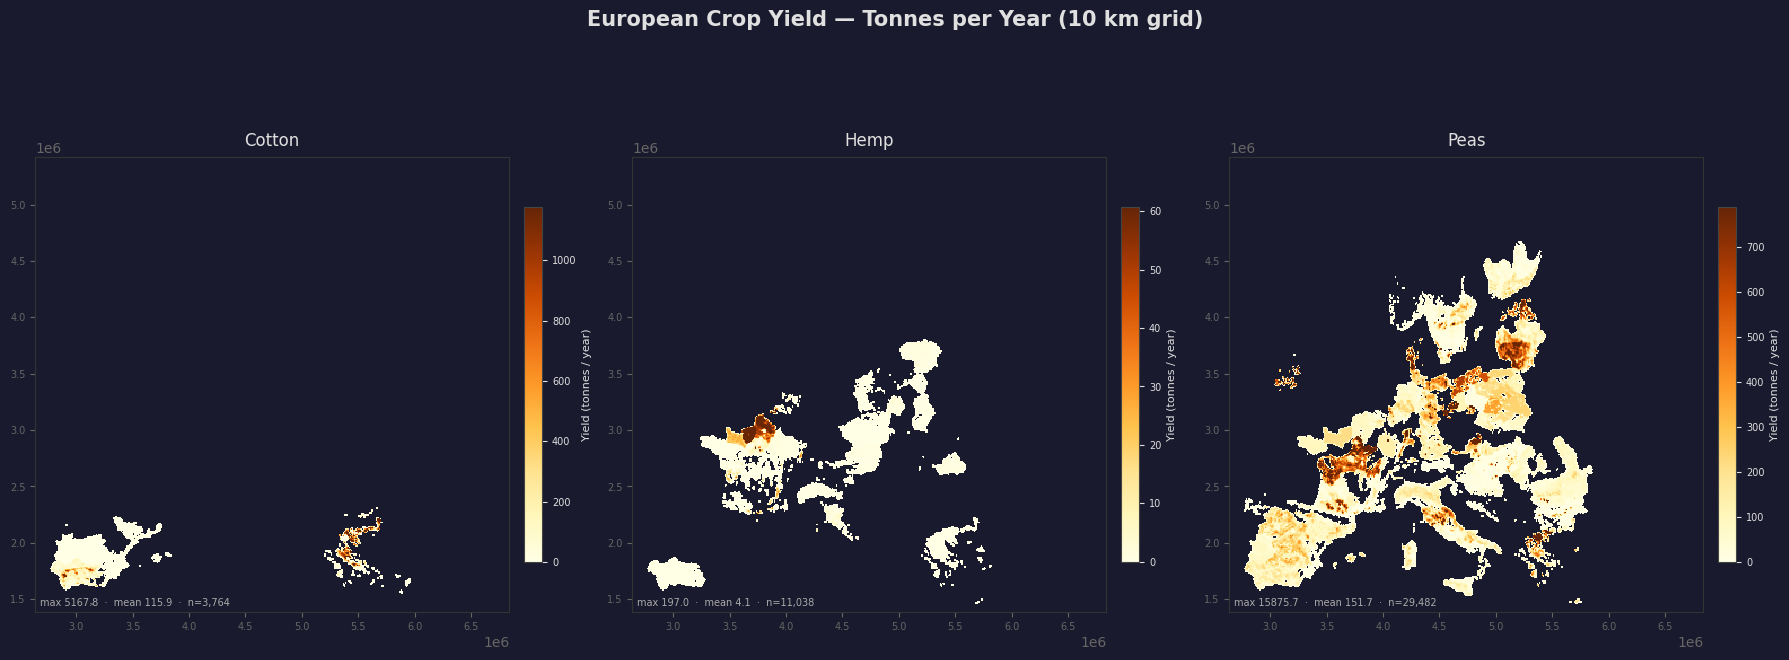

In [37]:
"""
Visualize yield (tonnes/year) rasters for Cotton, Hemp, and Peas side by side.
"""

import numpy as np
import rasterio
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────

FILES = {
    "Cotton":   "../../data/processed/spatial_data/crops/yield_tonnes_perYear_10km_Cotton.tif",
    "Hemp":     "../../data/processed/spatial_data/crops/yield_tonnes_perYear_10km_HempDust.tif",
    "Peas":     "../../data/processed/spatial_data/crops/yield_tonnes_perYear_10km_Peas.tif",
}

CMAP      = "YlOrBr"
BG_COLOR  = "#1a1a2e"
TEXT_COLOR = "#e0e0e0"

# ── Load rasters ──────────────────────────────────────────────────────────────

datasets = {}
for label, path in FILES.items():
    with rasterio.open(path) as src:
        data   = src.read(1).astype(float)
        nodata = src.nodata
        bounds = src.bounds

    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)
    data = np.where(data <= 0, np.nan, data)

    datasets[label] = {"data": data, "bounds": bounds}

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 7), facecolor=BG_COLOR)
fig.suptitle(
    "European Crop Yield — Tonnes per Year (10 km grid)",
    color=TEXT_COLOR, fontsize=15, fontweight="bold", y=1.01
)

for ax, (label, ds) in zip(axes, datasets.items()):
    data   = ds["data"]
    bounds = ds["bounds"]
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    vmax = np.nanpercentile(data, 98)

    cmap = plt.get_cmap(CMAP).copy()
    cmap.set_bad(color=BG_COLOR)

    im = ax.imshow(
        data,
        extent=extent,
        origin="upper",
        cmap=cmap,
        interpolation="nearest",
        vmin=0,
        vmax=vmax,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR, labelcolor=TEXT_COLOR, labelsize=7)
    cbar.outline.set_edgecolor("#444444")
    cbar.set_label("Yield (tonnes / year)", color=TEXT_COLOR, fontsize=8)

    valid = data[~np.isnan(data)]
    stats = f"max {np.nanmax(data):.1f}  ·  mean {np.nanmean(data):.1f}  ·  n={len(valid):,}"
    ax.text(
        0.01, 0.01, stats,
        transform=ax.transAxes,
        color="#aaaaaa", fontsize=7, va="bottom",
        bbox=dict(facecolor=BG_COLOR, edgecolor="none", alpha=0.7, pad=2),
    )

    ax.set_title(label, color=TEXT_COLOR, fontsize=12, pad=8)
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors="#666666", labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

## Forestry data - bark and sawdust

### S2BIOM data - all European countries except for Russia, Switzerland, and Norway

#### Combine all country data on bark and sawdust into one

In [1]:
import pandas as pd
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
in_dir  = Path("../../data/raw_data/spatial_data/forestry_s2biom")
out_dir = Path("../../data/processed/spatial_data/forestry_s2biom")
out_dir.mkdir(parents=True, exist_ok=True)

# ── Biomass type IDs of interest ──────────────────────────────────────────────
# 4131 = bark, 4111 = sawdust conifers, 4112 = sawdust nonconifers
BARK_ID    = 4131
SAWDUST_IDS = [4111, 4112]

# ── Potentials and years to extract ───────────────────────────────────────────
POTENTIALS = ["TECH", "BASE", "UD01", "UD02", "UD03", "UD04",
              "UD05", "UD06", "UD07", "UD08", "UD09", "HIGH"]
YEARS      = [2012, 2020, 2030]

# ── Loop over all country files ───────────────────────────────────────────────
all_rows = []

for xlsx_path in sorted(in_dir.glob("data_*.xlsx")):
    country = xlsx_path.stem.replace("data_", "")  # e.g. "AT"
    print(f"Processing {country}...")

    xl = pd.ExcelFile(xlsx_path)

    for potential in POTENTIALS:
        for year in YEARS:
            sheet = f"dm_{potential}_{year}_kton"

            if sheet not in xl.sheet_names:
                continue  # not all potentials exist in all files

            df = pd.read_excel(xl, sheet_name=sheet, index_col=0)

            # Column headers are numeric type IDs — ensure they're integers
            df.columns = df.columns.astype(int)

            for nuts3_region, row in df.iterrows():
                bark    = row.get(BARK_ID, 0) or 0
                sawdust = sum(row.get(sid, 0) or 0 for sid in SAWDUST_IDS)

                all_rows.append({
                    "country":    country,
                    "nuts3":      nuts3_region,
                    "potential":  potential,
                    "year":       year,
                    "bark_kton":    bark,
                    "sawdust_kton": sawdust,
                })

# ── Assemble and save ─────────────────────────────────────────────────────────
result = pd.DataFrame(all_rows)
result = result.sort_values(["nuts3", "potential", "year"]).reset_index(drop=True)

out_path = out_dir / "wood_industry_residues_bark_sawdust_s2biom.csv"
result.to_csv(out_path, index=False)

print(f"\nDone — {len(result):,} rows saved to {out_path}")
print(result.head(10).to_string())

Processing AL...
Processing AT...
Processing BA...
Processing BE...
Processing BG...
Processing CY...
Processing CZ...
Processing DE...
Processing DK...
Processing EE...
Processing EL...
Processing ES...
Processing FI...
Processing FR...
Processing HR...
Processing HU...
Processing IE...
Processing IT...
Processing KS...
Processing LT...
Processing LU...
Processing LV...
Processing MD...
Processing ME...
Processing MK...
Processing MT...
Processing NL...
Processing PL...
Processing PT...
Processing RO...
Processing RS...
Processing SE...
Processing SI...
Processing SK...
Processing TR...
Processing UA...
Processing UK...

Done — 48,906 rows saved to ../../data/processed/spatial_data/forestry_s2biom/wood_industry_residues_bark_sawdust_s2biom.csv
  country  nuts3 potential  year  bark_kton  sawdust_kton
0      AL  AL111      BASE  2012        0.0     10.188074
1      AL  AL111      BASE  2020        0.0     10.741223
2      AL  AL111      BASE  2030        0.0     12.915766
3      AL  AL

#### Turn csv into spatial data (gpkg)

In [12]:
import geopandas as gpd
import pandas as pd

# ── Load NUTS3 geometries (2013 vintage) ──────────────────────────────────────
nuts3 = gpd.read_file(
    "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/"
    "NUTS_RG_10M_2013_4326_LEVL_3.geojson"
).to_crs("EPSG:3035")

# ── Clip to Europe boundary ───────────────────────────────────────────────────
boundary = gpd.read_file("../../data/processed/spatial_data/europe_boundary.gpkg")
nuts3 = gpd.clip(nuts3, boundary)

# ── Load S2BIOM CSV ───────────────────────────────────────────────────────────
df = pd.read_csv("../../data/processed/spatial_data/forestry_s2biom/wood_industry_residues_bark_sawdust_s2biom.csv")
df = df.rename(columns={"nuts3": "NUTS_ID", "bark_kton": "bark_kton_perYear", "sawdust_kton": "sawdust_kton_perYear"})

# ── Join all potentials/years onto geometry ───────────────────────────────────
gdf = nuts3.merge(df, on="NUTS_ID", how="left")

print(f"Total rows:         {len(gdf)}")
print(f"Matched (notna):    {gdf['bark_kton_perYear'].notna().sum()}")
print(f"Unmatched (NaN):    {gdf['bark_kton_perYear'].isna().sum()}")
print("\nUnmatched by country:")
print(gdf[gdf["bark_kton_perYear"].isna()]["CNTR_CODE"].value_counts().head(15))

# ── Save ──────────────────────────────────────────────────────────────────────
out_path = "../../data/processed/spatial_data/forestry_s2biom/wood_industry_residues_bark_sawdust_s2biom.gpkg"
gdf.to_file(out_path, driver="GPKG")
print(f"\nSaved: {out_path}")

Total rows:         44170
Matched (notna):    44121
Unmatched (NaN):    49

Unmatched by country:
CNTR_CODE
CH    26
NO    19
IS     2
ME     1
LI     1
Name: count, dtype: int64

Saved: ../../data/processed/spatial_data/forestry_s2biom/wood_industry_residues_bark_sawdust_s2biom.gpkg


#### Plot to check
[link to interactive map to check](https://s2biom.wenr.wur.nl/web/guest/biomass-supply#_48_INSTANCE_nYA0VqOhoRGM_%3Dhttps%253A%252F%252Fs2biom.wenr.wur.nl%252Fbiomasscostsupplyviewer%252Findex.html%253Fclassic%2526)

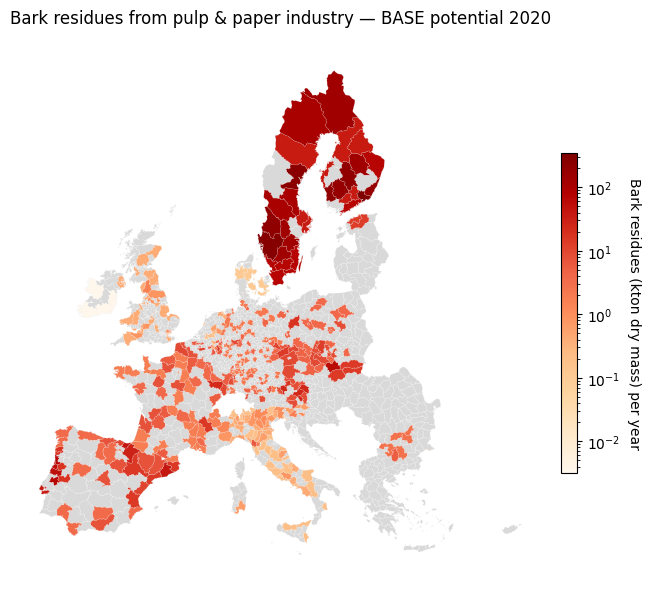

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

gdf = gpd.read_file("../../data/processed/spatial_data/forestry_s2biom/wood_industry_residues_bark_sawdust_s2biom.gpkg")
subset = gdf[(gdf.potential == "BASE") & (gdf.year == 2020)]

fig, ax = plt.subplots(figsize=(8, 6))

# Layer 1: all regions in grey (covers zeros and NaN)
subset.plot(ax=ax, color="#d9d9d9", linewidth=0.1, edgecolor="white")

# Layer 2: regions with bark > 0, colored by log scale
has_bark = subset[subset.bark_kton_perYear > 0]
norm = mcolors.LogNorm(vmin=has_bark.bark_kton_perYear.min(), vmax=has_bark.bark_kton_perYear.max())
has_bark.plot(ax=ax, column="bark_kton_perYear", cmap="OrRd",
              linewidth=0.1, edgecolor="white", norm=norm, legend=False)

sm = ScalarMappable(cmap="OrRd", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Bark residues (kton dry mass) per year", rotation=270, labelpad=15)

ax.set_title("Bark residues from pulp & paper industry — BASE potential 2020")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [65]:
gdf

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,NAME_ASCI,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,...,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,country,potential,year,bark_kton_perYear,sawdust_kton_perYear,geometry
0,EL431,3,EL,Irakleio,Ηράκλειο,Irakleio,Greece,Grèce,GRC,UN Member State,...,T,F,F,Griechenland,EL,BASE,"2,012.0",0.0,0.3,"MULTIPOLYGON (((5691831.095 1504402.065, 56923..."
1,EL431,3,EL,Irakleio,Ηράκλειο,Irakleio,Greece,Grèce,GRC,UN Member State,...,T,F,F,Griechenland,EL,BASE,"2,020.0",0.0,0.5,"MULTIPOLYGON (((5691831.095 1504402.065, 56923..."
2,EL431,3,EL,Irakleio,Ηράκλειο,Irakleio,Greece,Grèce,GRC,UN Member State,...,T,F,F,Griechenland,EL,BASE,"2,030.0",0.0,0.6,"MULTIPOLYGON (((5691831.095 1504402.065, 56923..."
3,EL431,3,EL,Irakleio,Ηράκλειο,Irakleio,Greece,Grèce,GRC,UN Member State,...,T,F,F,Griechenland,EL,HIGH,"2,012.0",0.0,0.0,"MULTIPOLYGON (((5691831.095 1504402.065, 56923..."
4,EL431,3,EL,Irakleio,Ηράκλειο,Irakleio,Greece,Grèce,GRC,UN Member State,...,T,F,F,Griechenland,EL,HIGH,"2,020.0",0.0,0.0,"MULTIPOLYGON (((5691831.095 1504402.065, 56923..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44165,UKM64,3,UK,Eilean Siar (Western Isles),Eilean Siar (Western Isles),Eilean Siar (Western Isles),United Kingdom,Royaume-Uni,GBR,UN Member State,...,T,F,F,Vereinigtes Königreich,UK,UD08,"2,012.0",0.0,0.0,"MULTIPOLYGON (((3371814.948 4009629.159, 33733..."
44166,UKM64,3,UK,Eilean Siar (Western Isles),Eilean Siar (Western Isles),Eilean Siar (Western Isles),United Kingdom,Royaume-Uni,GBR,UN Member State,...,T,F,F,Vereinigtes Königreich,UK,UD08,"2,020.0",0.0,0.0,"MULTIPOLYGON (((3371814.948 4009629.159, 33733..."
44167,UKM64,3,UK,Eilean Siar (Western Isles),Eilean Siar (Western Isles),Eilean Siar (Western Isles),United Kingdom,Royaume-Uni,GBR,UN Member State,...,T,F,F,Vereinigtes Königreich,UK,UD08,"2,030.0",0.0,0.0,"MULTIPOLYGON (((3371814.948 4009629.159, 33733..."
44168,IS001,3,IS,Höfuðborgarsvæði,Höfuðborgarsvæði,Hofudborgarsvaedi,Iceland,Islande,ISL,UN Member State,...,F,T,F,Island,None,None,NaN,NaN,NaN,"MULTIPOLYGON (((2824574.348 4887724.432, 28087..."


### National data for Norway, Switzerland, and Russia

### IIASA forest management data 
- For spatial disaggregation of S2BIOM data and national data for Russia, Norway, and Switzerland 
- Spatial resolution: 100m (original) --> 10km (Europe raster)

## Cellulose data (reject fines from paper industry)

### Eurostat data on paper production 

In [26]:
import pandas as pd
import openpyxl

# ── Config ────────────────────────────────────────────────────────────────────
FILE   = "../../data/raw_data/spatial_data/cellulose/eurostat_recycledPaper_ktons.xlsx"
OUTPUT = "../../data/processed/spatial_data/cellulose/recoveredPaper_byCountry_kton.csv"

YEARS = [2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015]  # priority order

# Rows to exclude (country column contains one of these)
DROP_COUNTRIES = {
    "European Union - 27 countries (from 2020)",
    "Special value",
    "Observation flags:",
    ":",          # legend row
    "b", "d", "e", "p",   # flag-definition rows
}

# ── Load all rows at once (avoids read_only iterator exhaustion) ──────────────
wb = openpyxl.load_workbook(FILE, read_only=False)
ws = wb["Sheet 1"]
all_rows = list(ws.iter_rows(values_only=True))

# ── Build year → column-index map from header row (row index 9, 0-based) ─────
header = all_rows[9]
year_to_colidx = {}
for i, val in enumerate(header):
    try:
        y = int(val)
        if y in YEARS:
            year_to_colidx[y] = i
    except (TypeError, ValueError):
        pass

print("Year → column index:", year_to_colidx)

# ── Parse data rows (row index 11 onward = Excel row 12+) ────────────────────
records = []

for row in all_rows[11:]:
    country = row[0]

    # Skip non-country rows
    if country is None:
        continue
    if not isinstance(country, str):
        continue
    if country.strip() in DROP_COUNTRIES or country.strip() == "":
        continue

    # Walk years from most recent to oldest, take first numeric value
    chosen_val  = None
    chosen_year = None

    for year in YEARS:
        ci = year_to_colidx.get(year)
        if ci is None or ci >= len(row):
            continue
        val = row[ci]
        if isinstance(val, (int, float)):
            chosen_val  = float(val)
            chosen_year = year
            break

    if chosen_val is None:
        continue   # no numeric data at all for this country

    records.append({
        "country":               country.strip(),
        "recovered_paper_kt":    chosen_val,
        "data_year":             chosen_year if chosen_year != 2024 else None,
    })

# ── Build DataFrame and save ──────────────────────────────────────────────────
df = pd.DataFrame(records, columns=["country", "recovered_paper_kt", "data_year"])
df["data_year"] = df["data_year"].astype("Int64")   # nullable int; blank for 2024
df = df.sort_values("recovered_paper_kt", ascending=False).reset_index(drop=True)
df['rejectedFines_kt'] = df['recovered_paper_kt'] * 0.15  # assume 15% of recovered paper becomes rejected fines (these are cellulose fibers that are too short to be reused as paper)

pd.set_option("display.float_format", "{:,.1f}".format)
print()
print(df.to_string(index=False))
print(f"\nRows: {len(df)}")
print(f"Countries with 2024 data:    {df['data_year'].isna().sum()}")
print(f"Countries with earlier data: {df['data_year'].notna().sum()}")

df.to_csv(OUTPUT, index=False)
print(f"\nSaved to: {OUTPUT}")

/Users/tsuitpy/miniconda3/envs/geo_env/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Year → column index: {2015: 1, 2016: 3, 2017: 5, 2018: 7, 2019: 9, 2020: 11, 2021: 13, 2022: 15, 2023: 17, 2024: 19}

    country  recovered_paper_kt  data_year  rejectedFines_kt
    Germany            12,398.8       <NA>           1,859.8
     France             6,399.0       <NA>             959.8
      Italy             5,221.1       <NA>             783.2
      Spain             4,456.2       <NA>             668.4
     Poland             3,450.0       <NA>             517.5
Netherlands             2,124.0       2023             318.6
    Austria             1,547.0       2023             232.0
Switzerland             1,141.2       2023             171.2
    Belgium             1,116.4       <NA>             167.5
    Czechia             1,009.0       <NA>             151.3
   Portugal               970.0       <NA>             145.5
     Sweden               926.0       <NA>             138.9
     Greece               821.3       2023             123.2
    Denmark               61

In [30]:
# ── Cell 1: Imports & paths ───────────────────────────────────────────────────
import pathlib
import urllib.request
import zipfile
import tempfile
from io import BytesIO

import pandas as pd
import geopandas as gpd

CSV_PATH = pathlib.Path("../../data/processed/spatial_data/cellulose/recoveredPaper_byCountry_kton.csv").resolve()
OUT_DIR  = CSV_PATH.parent
OUT_GPKG    = OUT_DIR / "cellulose_rejectedFines_Europe.gpkg"
OUT_GEOJSON = OUT_DIR / "cellulose_rejectedFines_Europe.geojson"

# ── Cell 2: Load CSV ──────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
df["country"] = df["country"].str.strip()
print(f"{len(df)} rows, columns: {list(df.columns)}")
display(df.head())

# ── Cell 3: Download Natural Earth country polygons ───────────────────────────
NE_URLS = [
    "https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_countries.zip",
    "https://github.com/nvkelso/natural-earth-vector/releases/download/v5.1.2/ne_50m_admin_0_countries.zip",
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_50m_admin_0_countries.geojson",
]

headers = {"User-Agent": "Mozilla/5.0"}
world = None

for url in NE_URLS:
    try:
        print(f"Trying {url[:60]}…")
        req = urllib.request.Request(url, headers=headers)
        with urllib.request.urlopen(req, timeout=30) as resp:
            raw = resp.read()
        if url.endswith(".geojson"):
            with tempfile.NamedTemporaryFile(suffix=".geojson", delete=False) as f:
                f.write(raw); tmp = f.name
            world = gpd.read_file(tmp)
        else:
            with zipfile.ZipFile(BytesIO(raw)) as z:
                tmpdir = tempfile.mkdtemp()
                z.extractall(tmpdir)
                shp = next(pathlib.Path(tmpdir).rglob("*.shp"))
            world = gpd.read_file(shp)
        print(f"✓ Loaded {len(world)} countries")
        break
    except Exception as e:
        print(f"  failed: {e}")

# ── Cell 4: Name harmonisation & merge ────────────────────────────────────────
MANUAL_MAP = {
    "Czech Republic"  : "Czechia",
    "Slovak Republic" : "Slovakia",
    "Bosnia and Herz.": "Bosnia and Herzegovina",
}

name_col = "NAME" if "NAME" in world.columns else "name"
world["csv_name"] = world[name_col].apply(lambda n: MANUAL_MAP.get(n, n))

merged = world.merge(df, left_on="csv_name", right_on="country", how="right")

no_geom = merged[merged.geometry.isna()]["country"].tolist()
if no_geom:
    print(f"⚠ No geometry for: {no_geom} — add to MANUAL_MAP and rerun")
else:
    print(f"✓ All {len(merged)} countries matched")

merged = merged[merged.geometry.notna()].copy()
merged = merged[["country", "recovered_paper_kt", "data_year", "rejectedFines_kt", "geometry"]]
merged = gpd.GeoDataFrame(merged, geometry="geometry").set_crs(epsg=4326)
display(merged.head())

# ── Cell 5: Write outputs ─────────────────────────────────────────────────────
merged.to_file(OUT_GEOJSON, driver="GeoJSON")
merged.to_crs(epsg=3035).to_file(OUT_GPKG, driver="GPKG", layer="cellulose_rejectedFines")

print(f"GeoJSON (WGS84):        {OUT_GEOJSON}")
print(f"GeoPackage (EPSG 3035): {OUT_GPKG}")

merged[["country", "rejectedFines_kt"]].sort_values("rejectedFines_kt", ascending=False)

30 rows, columns: ['country', 'recovered_paper_kt', 'data_year', 'rejectedFines_kt']


,country,recovered_paper_kt,data_year,rejectedFines_kt
0,Germany,"12,398.8",NaN,"1,859.8"
1,France,"6,399.0",NaN,959.9
2,Italy,"5,221.1",NaN,783.2
3,Spain,"4,456.2",NaN,668.4
4,Poland,"3,450.0",NaN,517.5


Trying https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_…
✓ Loaded 242 countries
✓ All 30 countries matched


,country,recovered_paper_kt,data_year,rejectedFines_kt,geometry
0,Germany,"12,398.8",NaN,"1,859.8","MULTIPOLYGON (((9.52402 47.52422, 9.35 47.5989..."
1,France,"6,399.0",NaN,959.9,"MULTIPOLYGON (((9.48037 42.80542, 9.4542 42.65..."
2,Italy,"5,221.1",NaN,783.2,"MULTIPOLYGON (((7.02109 45.92578, 7.05576 45.9..."
3,Spain,"4,456.2",NaN,668.4,"MULTIPOLYGON (((1.59395 38.67207, 1.57119 38.6..."
4,Poland,"3,450.0",NaN,517.5,"POLYGON ((23.60527 51.51792, 23.65889 51.44897..."


GeoJSON (WGS84):        /Users/tsuitpy/Library/CloudStorage/OneDrive-UniversiteitLeiden/01_Projects/RAW/lca_for_adaptive_factories/data/processed/spatial_data/cellulose/cellulose_rejectedFines_Europe.geojson
GeoPackage (EPSG 3035): /Users/tsuitpy/Library/CloudStorage/OneDrive-UniversiteitLeiden/01_Projects/RAW/lca_for_adaptive_factories/data/processed/spatial_data/cellulose/cellulose_rejectedFines_Europe.gpkg


,country,rejectedFines_kt
0,Germany,"1,859.8"
1,France,959.9
2,Italy,783.2
3,Spain,668.4
4,Poland,517.5
5,Netherlands,318.6
6,Austria,232.1
7,Switzerland,171.2
8,Belgium,167.5
9,Czechia,151.3


### SFI (spatial finance initiative) dataset

In [66]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

MILLS_XLSX  = Path("../../data/raw_data/spatial_data/cellulose/paper_SFI/SFI_ALD_Pulp_Paper_Database_July_2025.xlsx")
FINES_GPKG  = Path("../../data/processed/spatial_data/cellulose/cellulose_rejectedFines_Europe.gpkg")
OUT_DIR     = FINES_GPKG.parent
OUT_GPKG    = OUT_DIR / "cellulose_rejectedFines_mills_disaggregated.gpkg"
OUT_GEOJSON = OUT_DIR / "cellulose_rejectedFines_mills_disaggregated.geojson"

df = pd.read_excel(MILLS_XLSX, sheet_name="SFI_Pulp_Paper_Database", header=0)
df.columns = df.columns.str.strip()
df["plant_type"] = df["plant_type"].str.strip().str.lower()

# ── Filter to active European paper mills only ────────────────────────────────
PAPER_TYPES = {"paper", "paper and packaging", "pulp and paper",
               "pulp and paper and packaging", "pulp, paper, and packaging",
               "recycled paper"}

active_paper_mills = df[
    (df["region"]     == "Europe") &
    (df["status"]     == "Operating") &
    (df["plant_type"].isin(PAPER_TYPES))        # ← this was missing
].copy()

print(f"Active European paper mills: {len(active_paper_mills)}")
print(f"\nplant_type breakdown:")
print(active_paper_mills["plant_type"].value_counts().to_string())
print(f"\nCountry breakdown:")
print(active_paper_mills["country"].value_counts().to_string())

active_paper_mills["latitude"]  = pd.to_numeric(active_paper_mills["latitude"],  errors="coerce")
active_paper_mills["longitude"] = pd.to_numeric(active_paper_mills["longitude"], errors="coerce")
active_paper_mills = active_paper_mills.dropna(subset=["latitude", "longitude"])

mills_gdf = gpd.GeoDataFrame(
    active_paper_mills,
    geometry=gpd.points_from_xy(active_paper_mills["longitude"], active_paper_mills["latitude"]),
    crs="EPSG:4326"
)

fines_gdf = gpd.read_file(FINES_GPKG)

COUNTRY_NAME_MAP = {
    "Czech Republic" : "Czechia",
    "Slovak Republic": "Slovakia",
}
mills_gdf["country_matched"] = mills_gdf["country"].replace(COUNTRY_NAME_MAP)

mill_counts = mills_gdf.groupby("country_matched").size().reset_index(name="n_mills")
fines_lookup = fines_gdf[["country", "rejectedFines_kt"]].copy()

allocation = mill_counts.merge(fines_lookup, left_on="country_matched", right_on="country", how="left")
allocation["rejectedFines_kt_per_mill"] = allocation["rejectedFines_kt"] / allocation["n_mills"]

mills_disagg = mills_gdf.merge(
    allocation[["country_matched", "n_mills", "rejectedFines_kt", "rejectedFines_kt_per_mill"]],
    on="country_matched", how="left"
)
mills_disagg = mills_disagg.dropna(subset=["rejectedFines_kt_per_mill"])

keep_cols = ["uid", "plant_name", "city", "country", "country_matched",
             "latitude", "longitude", "n_mills", "rejectedFines_kt",
             "rejectedFines_kt_per_mill", "plant_type", "products", "geometry"]
mills_disagg = mills_disagg[[c for c in keep_cols if c in mills_disagg.columns]].copy()

mills_disagg.set_crs("EPSG:4326", allow_override=True).to_file(OUT_GEOJSON, driver="GeoJSON")
mills_disagg.set_crs("EPSG:4326", allow_override=True).to_crs(epsg=3035).to_file(
    OUT_GPKG, driver="GPKG", layer="rejectedFines_disaggregated"
)
print(f"\n✓ {len(mills_disagg)} mills written to {OUT_GPKG}")

Active European paper mills: 805

plant_type breakdown:
plant_type
paper                           662
paper and packaging             111
pulp and paper                   30
pulp and paper and packaging      2

Country breakdown:
country
Italy                     146
Germany                   130
Sweden                     85
France                     79
Spain                      57
Turkey                     38
United Kingdom             34
Finland                    27
Austria                    26
Poland                     24
Ukraine                    24
Netherlands                21
Czech Republic             14
Switzerland                13
Portugal                   11
Belgium                     9
Belarus                     9
Bulgaria                    8
Norway                      7
Romania                     7
Slovenia                    6
Greece                      5
Slovak Republic             5
Serbia                      3
Bosnia and Herzegovina      3
Estonia    

### Aggregate to Europe raster

In [67]:
# ── Cell 1: Imports & paths ───────────────────────────────────────────────────
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds
from pathlib import Path

MILLS_GPKG   = Path("../../data/processed/spatial_data/cellulose/cellulose_rejectedFines_mills_disaggregated.gpkg")
TEMPLATE_TIF = Path("../../data/processed/spatial_data/europe_boundary_10km.tif")
OUT_TIF      = Path("../../data/processed/yield_maps/yield_tonnes_perYear_10km_cellulose.tif")
OUT_TIF.parent.mkdir(parents=True, exist_ok=True)

# ── Cell 2: Load disaggregated mill points ────────────────────────────────────
mills = gpd.read_file(MILLS_GPKG, layer="rejectedFines_disaggregated")
print(f"Mills loaded: {len(mills)}, CRS: {mills.crs}")

# Ensure we're in EPSG:3035 to match the raster
if mills.crs.to_epsg() != 3035:
    mills = mills.to_crs(epsg=3035)
    print("Reprojected mills to EPSG:3035")

# Convert kt → tonnes (1 kt = 1000 t)
mills["rejectedFines_t"] = mills["rejectedFines_kt_per_mill"] * 1000
print(f"\nTotal rejected fines across all mills: {mills['rejectedFines_t'].sum():,.0f} t/yr")

# ── Cell 3: Inspect template raster ──────────────────────────────────────────
with rasterio.open(TEMPLATE_TIF) as src:
    profile  = src.profile.copy()
    transform = src.transform
    shape    = (src.height, src.width)
    nodata   = src.nodata
    bounds   = src.bounds
    crs      = src.crs

print(f"Template raster:")
print(f"  Shape:     {shape[0]} rows × {shape[1]} cols")
print(f"  Transform: {transform}")
print(f"  CRS:       {crs}")
print(f"  NoData:    {nodata}")
print(f"  Bounds:    {bounds}")

# ── Cell 4: Rasterize — sum mill tonnes into each 10 km cell ─────────────────
# Each mill point burns its rejectedFines_t value into the cell it falls in.
# Points in the same cell are summed via a two-pass approach (rasterize takes
# the last value by default; we sum manually instead).

height, width = shape

# Build an accumulator grid (float32, zeros)
grid = np.zeros((height, width), dtype=np.float32)

# Map each mill point to a pixel and accumulate
for _, row in mills.iterrows():
    x, y = row.geometry.x, row.geometry.y
    # Convert map coords → pixel indices
    col, row_idx = ~transform * (x, y)   # inverse affine
    col, row_idx = int(col), int(row_idx)
    if 0 <= row_idx < height and 0 <= col < width:
        grid[row_idx, col] += row["rejectedFines_t"]

# Set cells outside the Europe boundary to nodata
# (use the template raster mask — 0 or nodata = outside)
with rasterio.open(TEMPLATE_TIF) as src:
    template_data = src.read(1)
    template_mask = (
        (template_data == nodata) | np.isnan(template_data)
        if nodata is not None
        else np.isnan(template_data)
    )

grid[template_mask] = np.nan

# Quick summary of non-zero cells
n_cells = int((grid > 0).sum())
total_t  = float(np.nansum(grid))
print(f"\nCells with mills assigned: {n_cells}")
print(f"Total tonnes in raster:    {total_t:,.0f} t/yr")
print(f"Expected (from mills):     {mills['rejectedFines_t'].sum():,.0f} t/yr")

# ── Diagnostic: mills that fell outside the raster extent ────────────────────
unassigned = []
for _, row in mills.iterrows():
    x, y = row.geometry.x, row.geometry.y
    col, row_idx = ~transform * (x, y)
    col, row_idx = int(col), int(row_idx)
    if not (0 <= row_idx < height and 0 <= col < width):
        unassigned.append({
            "plant_name": row["plant_name"],
            "country":    row["country"],
            "x_3035":     round(x),
            "y_3035":     round(y),
            "col_pixel":  col,
            "row_pixel":  row_idx,
            "reason":     "outside raster extent"
        })
    elif template_mask[row_idx, col]:
        unassigned.append({
            "plant_name": row["plant_name"],
            "country":    row["country"],
            "x_3035":     round(x),
            "y_3035":     round(y),
            "col_pixel":  col,
            "row_pixel":  row_idx,
            "reason":     "nodata cell in template"
        })

unassigned_df = pd.DataFrame(unassigned)
print(f"Unassigned mills: {len(unassigned_df)}")
print(f"\nBreakdown by reason:")
print(unassigned_df["reason"].value_counts().to_string())
print(f"\nBreakdown by country:")
print(unassigned_df.groupby(["country", "reason"]).size().to_string())
print(f"\nFull list:")
display(unassigned_df.sort_values(["country", "plant_name"]))

# ── Cell 4: Rasterize with snapping for nodata-cell mills ────────────────────
from scipy.ndimage import distance_transform_edt

height, width = shape

grid = np.zeros((height, width), dtype=np.float32)

# Load template mask once
with rasterio.open(TEMPLATE_TIF) as src:
    template_data = src.read(1)
    template_mask = (
        (template_data == nodata) | np.isnan(template_data)
        if nodata is not None
        else np.isnan(template_data)
    )

# Valid land cells = where template_mask is False
valid_land = ~template_mask

# Precompute nearest valid cell for every pixel using distance transform
# distance_transform_edt returns, for each invalid cell, the index of the
# nearest valid cell — we use this to snap offshore points to land
_, nearest_indices = distance_transform_edt(
    ~valid_land, return_distances=True, return_indices=True
)
# nearest_indices shape: (2, height, width) — [row, col] of nearest valid cell

SNAP_RADIUS_CELLS = 3   # max snap distance = 3 × 10 km = 30 km

assigned   = []
unassigned = []

for _, row in mills.iterrows():
    x, y = row.geometry.x, row.geometry.y
    col, row_idx = ~transform * (x, y)
    col, row_idx = int(col), int(row_idx)

    # Case 1: outside raster extent entirely
    if not (0 <= row_idx < height and 0 <= col < width):
        unassigned.append({
            "plant_name": row["plant_name"],
            "country":    row["country"],
            "reason":     "outside raster extent"
        })
        continue

    # Case 2: lands on a valid land cell — assign directly
    if valid_land[row_idx, col]:
        grid[row_idx, col] += row["rejectedFines_t"]
        assigned.append(row["plant_name"])
        continue

    # Case 3: lands on nodata cell — snap to nearest valid land cell
    snap_row = nearest_indices[0, row_idx, col]
    snap_col = nearest_indices[1, row_idx, col]
    snap_dist = max(abs(snap_row - row_idx), abs(snap_col - col))  # Chebyshev distance

    if snap_dist <= SNAP_RADIUS_CELLS:
        grid[snap_row, snap_col] += row["rejectedFines_t"]
        assigned.append(row["plant_name"])
    else:
        unassigned.append({
            "plant_name": row["plant_name"],
            "country":    row["country"],
            "reason":     f"nearest land cell {snap_dist} cells away (> {SNAP_RADIUS_CELLS} limit)"
        })

# Mask non-Europe cells
grid[template_mask] = np.nan

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"Assigned:   {len(assigned)} mills")
print(f"Unassigned: {len(unassigned)} mills")

if unassigned:
    unassigned_df = pd.DataFrame(unassigned)
    print(f"\nUnassigned breakdown:")
    print(unassigned_df.groupby(["country", "reason"]).size().to_string())
    display(unassigned_df)

n_cells = int((grid > 0).sum())
total_t  = float(np.nansum(grid))
print(f"\nCells with values: {n_cells}")
print(f"Total tonnes in raster: {total_t:,.0f} t/yr")
print(f"Expected (from mills):  {mills['rejectedFines_t'].sum():,.0f} t/yr")

# ── Cell 5: Write output raster ───────────────────────────────────────────────
out_profile = profile.copy()
out_profile.update({
    "dtype"   : "float32",
    "count"   : 1,
    "nodata"  : np.nan,
    "compress": "lzw",
})

with rasterio.open(OUT_TIF, "w", **out_profile) as dst:
    dst.write(grid, 1)
    dst.update_tags(
        description="Cellulose rejected fines from recovered paper, disaggregated to paper mill locations",
        units="tonnes per year",
        resolution="10 km",
        crs="EPSG:3035",
        source_national="cellulose_rejectedFines_Europe.gpkg",
        source_mills="cellulose_rejectedFines_mills_disaggregated.gpkg",
    )

print(f"\n✓ Raster written to: {OUT_TIF}")

Mills loaded: 687, CRS: EPSG:3035

Total rejected fines across all mills: 6,611,488 t/yr
Template raster:
  Shape:     404 rows × 421 cols
  Transform: | 9987.27, 0.00, 2635414.64|
| 0.00,-9996.01, 5424003.95|
| 0.00, 0.00, 1.00|
  CRS:       EPSG:3035
  NoData:    0.0
  Bounds:    BoundingBox(left=2635414.6405488187, bottom=1385617.5905475067, right=6840056.918320155, top=5424003.94682701)

Cells with mills assigned: 514
Total tonnes in raster:    6,478,587 t/yr
Expected (from mills):     6,611,488 t/yr
Unassigned mills: 20

Breakdown by reason:
reason
nodata cell in template    19
outside raster extent       1

Breakdown by country:
country   reason                 
Finland   nodata cell in template    4
Greece    nodata cell in template    2
Italy     nodata cell in template    1
          outside raster extent      1
Norway    nodata cell in template    1
Portugal  nodata cell in template    2
Spain     nodata cell in template    1
Sweden    nodata cell in template    8

Full list:

,plant_name,country,x_3035,y_3035,col_pixel,row_pixel,reason
1,Ahlstrom Corporation,Finland,5145181,4206800,251,121,nodata cell in template
4,Billerud Finland Oy,Finland,4948906,4567959,231,85,nodata cell in template
2,Pine Chemical Group Oy,Finland,5146240,4205060,251,121,nodata cell in template
3,UPM Group - Paper Industry,Finland,5146088,4206000,251,121,nodata cell in template
5,Patras Paper Mills S.A.,Greece,5350324,1760575,271,366,nodata cell in template
6,"VIS Containers Manufacturing Co Ltd, Volos Mills",Greece,5437510,1903802,280,352,nodata cell in template
8,"Cartiera Confalone SPA, Cartiera e Sede legale",Italy,4715170,1962961,208,346,nodata cell in template
7,Cartiere Rodolfo Reguzzoni S.r.l.,Italy,-1606159,7080305,-424,-165,outside raster extent
9,MM FOLLACELL AS,Norway,4375318,4542702,174,88,nodata cell in template
10,Fábrica de Papel Ponte Redonda S.A.,Portugal,2765219,2179744,12,324,nodata cell in template


Assigned:   686 mills
Unassigned: 1 mills

Unassigned breakdown:
country  reason               
Italy    outside raster extent    1


,plant_name,country,reason
0,Cartiere Rodolfo Reguzzoni S.r.l.,Italy,outside raster extent



Cells with values: 524
Total tonnes in raster: 6,606,124 t/yr
Expected (from mills):  6,611,488 t/yr

✓ Raster written to: ../../data/processed/yield_maps/yield_tonnes_perYear_10km_cellulose.tif


In [68]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from scipy.ndimage import distance_transform_edt
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
MILLS_GPKG   = Path("../../data/processed/spatial_data/cellulose/cellulose_rejectedFines_mills_disaggregated.gpkg")
TEMPLATE_TIF = Path("../../data/processed/spatial_data/europe_boundary_10km.tif")
OUT_TIF      = Path("../../data/processed/yield_maps/yield_tonnes_perYear_10km_cellulose.tif")
OUT_TIF.parent.mkdir(parents=True, exist_ok=True)

# ── Load mills, reproject, convert kt → t ────────────────────────────────────
mills = gpd.read_file(MILLS_GPKG, layer="rejectedFines_disaggregated").to_crs(epsg=3035)
mills["rejectedFines_t"] = mills["rejectedFines_kt_per_mill"] * 1000

# ── Load template raster ──────────────────────────────────────────────────────
with rasterio.open(TEMPLATE_TIF) as src:
    profile   = src.profile.copy()
    transform = src.transform
    height, width = src.height, src.width
    template  = src.read(1)
    nodata    = src.nodata

valid_land = ~((template == nodata) | np.isnan(template)) if nodata is not None else ~np.isnan(template)
_, nearest = distance_transform_edt(~valid_land, return_indices=True)

# ── Rasterize with snapping ───────────────────────────────────────────────────
SNAP_RADIUS_CELLS = 10
grid = np.zeros((height, width), dtype=np.float32)

for _, row in mills.iterrows():
    c, r = ~transform * (row.geometry.x, row.geometry.y)
    c, r = int(c), int(r)
    if not (0 <= r < height and 0 <= c < width):
        continue
    if not valid_land[r, c]:
        nr, nc = nearest[0, r, c], nearest[1, r, c]
        if max(abs(nr - r), abs(nc - c)) > SNAP_RADIUS_CELLS:
            continue
        r, c = nr, nc
    grid[r, c] += row["rejectedFines_t"]

grid[~valid_land] = np.nan

# ── Write output ──────────────────────────────────────────────────────────────
out_profile = profile.copy()
out_profile.update({"dtype": "float32", "count": 1, "nodata": np.nan, "compress": "lzw"})

with rasterio.open(OUT_TIF, "w", **out_profile) as dst:
    dst.write(grid, 1)

print(f"✓ Written: {OUT_TIF}")

✓ Written: ../../data/processed/yield_maps/yield_tonnes_perYear_10km_cellulose.tif


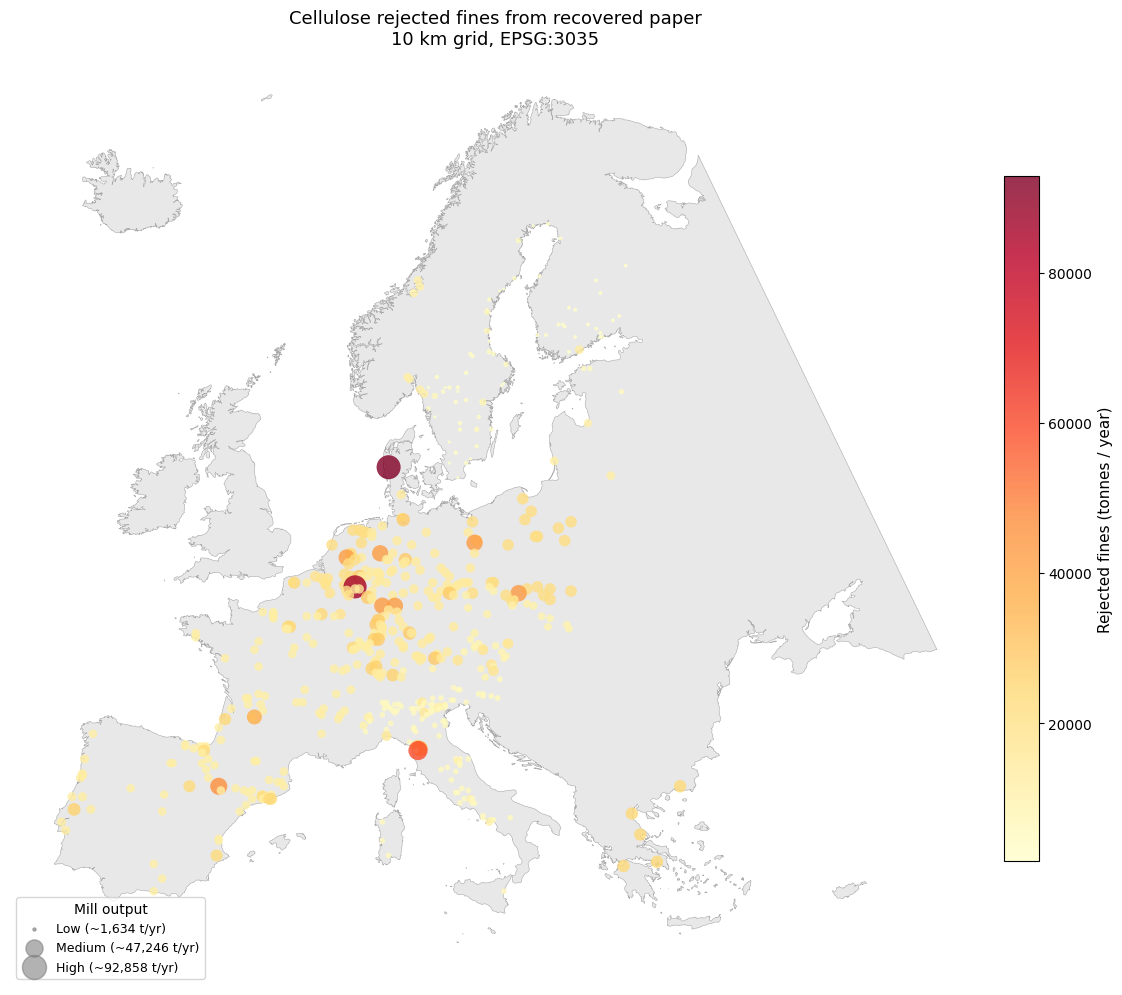

In [69]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.transform import xy
from pathlib import Path

EUROPE_GPKG = Path("../../data/processed/spatial_data/europe_boundary.gpkg")

# ── Raster → points ───────────────────────────────────────────────────────────
with rasterio.open(OUT_TIF) as src:
    data      = src.read(1)
    transform = src.transform
    height, width = src.height, src.width

rows, cols = np.where(data > 0)
values     = data[rows, cols]
xs, ys     = xy(transform, rows, cols)

points = gpd.GeoDataFrame(
    {"tonnes": values},
    geometry=gpd.points_from_xy(xs, ys),
    crs="EPSG:3035"
)

# ── Load Europe boundary ──────────────────────────────────────────────────────
europe = gpd.read_file(EUROPE_GPKG).to_crs(epsg=3035)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 14))

europe.plot(ax=ax, color="#e8e8e8", edgecolor="#aaaaaa", linewidth=0.4)

# Scale point sizes: normalise to a readable range
size_min, size_max = 5, 300
t_min, t_max = points["tonnes"].min(), points["tonnes"].max()
sizes = size_min + (points["tonnes"] - t_min) / (t_max - t_min) * (size_max - size_min)

sc = ax.scatter(
    [geom.x for geom in points.geometry],
    [geom.y for geom in points.geometry],
    s=sizes,
    c=points["tonnes"],
    cmap="YlOrRd",
    alpha=0.8,
    linewidths=0,
)

cbar = fig.colorbar(sc, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label("Rejected fines (tonnes / year)", fontsize=11)

# Legend for point sizes
for label, frac in [("Low", 0.0), ("Medium", 0.5), ("High", 1.0)]:
    s = size_min + frac * (size_max - size_min)
    t = t_min    + frac * (t_max - t_min)
    ax.scatter([], [], s=s, c="grey", alpha=0.6, label=f"{label} (~{t:,.0f} t/yr)")
ax.legend(title="Mill output", loc="lower left", framealpha=0.8, fontsize=9)

ax.set_title("Cellulose rejected fines from recovered paper\n10 km grid, EPSG:3035", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

### Sanity check - are the amounts consistent? 
Not fully - no data for Ireland, Malta, and Cyprus. But the loss is so small (~1%) that I'm just going to leave it that way. 

In [70]:
import pandas as pd
import geopandas as gpd
import rasterio
import numpy as np
from pathlib import Path

# ── File paths ────────────────────────────────────────────────────────────────
CSV_PATH   = Path("../../data/processed/spatial_data/cellulose/recoveredPaper_byCountry_kton.csv")
FINES_GPKG = Path("../../data/processed/spatial_data/cellulose/cellulose_rejectedFines_Europe.gpkg")
MILLS_GPKG = Path("../../data/processed/spatial_data/cellulose/cellulose_rejectedFines_mills_disaggregated.gpkg")
OUT_TIF    = Path("../../data/processed/yield_maps/yield_tonnes_perYear_10km_cellulose.tif")

# ── Step 1: Eurostat CSV ──────────────────────────────────────────────────────
eurostat = pd.read_csv(CSV_PATH)
eurostat_total_kt = eurostat["rejectedFines_kt"].sum()

# ── Step 2: National GeoPackage (should match Step 1 exactly) ────────────────
fines = gpd.read_file(FINES_GPKG)
fines_total_kt = fines["rejectedFines_kt"].sum()

# ── Step 3: Disaggregated mills (sum per country should match Step 1) ─────────
mills = gpd.read_file(MILLS_GPKG, layer="rejectedFines_disaggregated")
mills_by_country = mills.groupby("country_matched")["rejectedFines_kt_per_mill"].sum().reset_index()
mills_by_country.columns = ["country", "reaggregated_kt"]
mills_total_kt = mills_by_country["reaggregated_kt"].sum()

# ── Step 4: Raster (convert t → kt, should approximately match) ───────────────
with rasterio.open(OUT_TIF) as src:
    data = src.read(1)
raster_total_kt = float(np.nansum(data)) / 1000

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    "step": ["1. Eurostat CSV", "2. National GeoPackage", "3. Disaggregated mills", "4. Raster"],
    "total_rejectedFines_kt": [eurostat_total_kt, fines_total_kt, mills_total_kt, raster_total_kt],
})
summary["diff_from_eurostat_kt"] = summary["total_rejectedFines_kt"] - eurostat_total_kt
summary["match"] = summary["diff_from_eurostat_kt"].abs() < 0.1

display(summary)

# ── Per-country comparison: Eurostat vs mills ─────────────────────────────────
country_check = eurostat[["country", "rejectedFines_kt"]].merge(
    mills_by_country, on="country", how="outer"
).fillna(0)
country_check["diff_kt"] = (country_check["reaggregated_kt"] - country_check["rejectedFines_kt"]).round(4)
country_check["match"] = country_check["diff_kt"].abs() < 0.01

print("\nPer-country check (Eurostat vs reaggregated mills):")
display(country_check.sort_values("diff_kt", key=abs, ascending=False))

,step,total_rejectedFines_kt,diff_from_eurostat_kt,match
0,1. Eurostat CSV,"6,689.5",0.0,True
1,2. National GeoPackage,"6,689.5",0.0,True
2,3. Disaggregated mills,"6,611.5",-78.0,False
3,4. Raster,"6,606.1",-83.4,False



Per-country check (Eurostat vs reaggregated mills):


,country,rejectedFines_kt,reaggregated_kt,diff_kt,match
14,Ireland,65.1,0.0,-65.1,False
4,Cyprus,8.0,0.0,-8.0,False
19,Malta,4.9,0.0,-4.9,False
0,Austria,232.1,232.1,0.0,True
16,Latvia,11.2,11.2,0.0,True
28,Sweden,138.9,138.9,0.0,True
27,Spain,668.4,668.4,0.0,True
26,Slovenia,34.6,34.6,0.0,True
25,Slovakia,48.0,48.0,0.0,True
24,Romania,0.0,0.0,0.0,True


## Seagrass

### Seagrass meadow polygons - EMODnet
- EMODnet website: https://emodnet.ec.europa.eu/en/seabed-habitats#data
- Polygons website (derived from EMODnet): https://gis.ices.dk/geonetwork/srv/api/records/39746d9c-4220-425c-bc26-7cb3056c36a5 

#### Download and process data (takes ~4 mins)
- Filtered out polygons < 5m2, because these are most likely noise
- Filtered out polygons > 10km2, because these are most likely low resolution mapping of seagrass existence probability, rather than an actual seagrass meadow. 

In [ ]:
import geopandas as gpd

# download via WFS (slower, less reliable) — sometimes the server returns an error or empty response, so we use the direct download instead
# WFS_URL = (
#     "https://ows.emodnet-seabedhabitats.eu/geoserver/emodnet_open/wfs?"
#     "service=WFS&version=2.0.0&request=GetFeature"
#     "&typeName=emodnet_open:seagrass_eov_poly_2025"
#     "&outputFormat=application/json"
#     "&bbox=-30,34,50,72,EPSG:4326"
# )
# seagrass = gpd.read_file(WFS_URL)
# print(f"Loaded {len(seagrass)} features in CRS: {seagrass.crs}")

url = "https://files.emodnet-seabedhabitats.eu/data/SeagrassBeds_EOV_2025.zip"
seagrass = gpd.read_file(url, layer="seagrass_polygons_2025")
print(f"Loaded {len(seagrass)} features in CRS: {seagrass.crs}")

print(f"Columns: {seagrass.columns.tolist()}")
if 'FID' in seagrass.columns:
    seagrass = seagrass.rename(columns={'FID': 'source_fid'})

seagrass = seagrass.to_crs(epsg=3035)
print(f"Reprojected to: {seagrass.crs}")

seagrass['area_m2'] = seagrass.geometry.area
average_area_m2 = seagrass['area_m2'].mean()
print(f"Average seagrass meadow area: {average_area_m2:.1f} m²")

seagrass = seagrass[~seagrass.geometry.isna()]
seagrass = seagrass[~seagrass.geometry.is_empty]
seagrass = seagrass[seagrass.geometry.is_valid]
seagrass = seagrass[seagrass['area_m2'] >= 5] # filter out very small polygons that may be noise or errors
seagrass = seagrass[seagrass['area_m2'] <= 1e7] # filter out very large polygons that may be errors (10 km² is a reasonable upper bound for a single meadow)

output_path = "../../data/processed/spatial_data/seagrass/emodnet_seagrass_meadow_areas_3035.gpkg"
seagrass.to_file(output_path, driver="GPKG")
print(f"Saved to {output_path}")

Loaded 649590 features in CRS: EPSG:4326
Columns: ['id', 'habsubtype', 'objectid', 'map_id', 'hab_origin', 'eunis_code', 'eunis_name', 'anxi_code', 'anxi_name', 'ospar_hab', 'helcom_cod', 'helcom_nam', 'determiner', 'det_date', 'source', 'Shape_Leng', 'Shape_Area', 'geometry']
Reprojected to: EPSG:3035
Average seagrass meadow area: 53459.4 m²
Saved to ../../data/processed/spatial_data/seagrass/emodnet_seagrass_meadow_areas_3035.gpkg


#### Visualize distribution of meadow area

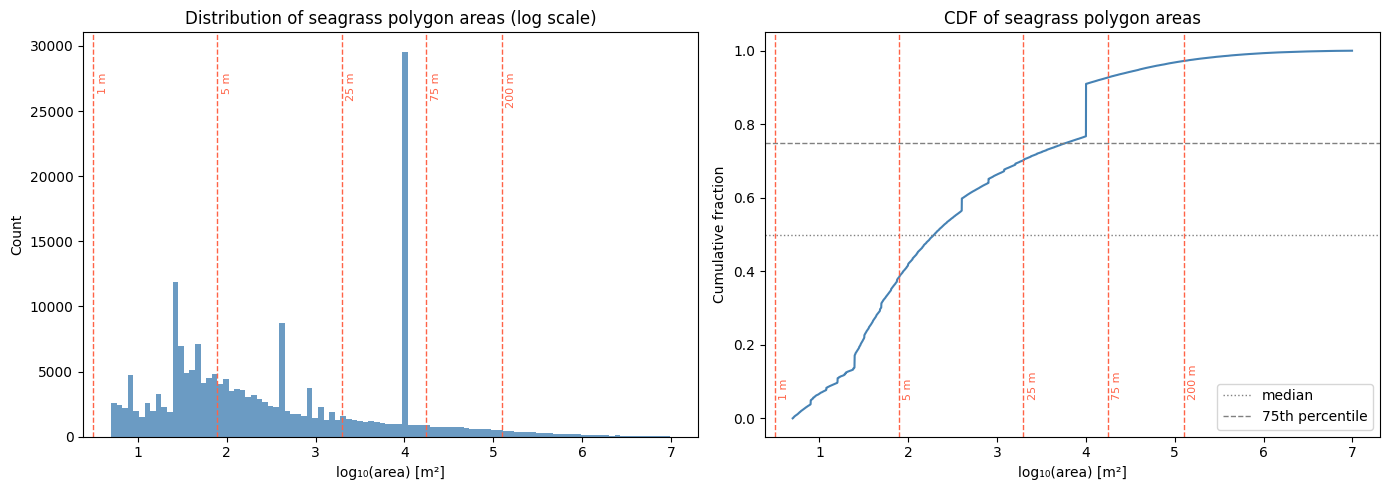

In [60]:
import matplotlib.pyplot as plt
import numpy as np

seagrass = gpd.read_file("../../data/processed/spatial_data/seagrass/emodnet_seagrass_meadow_areas_3035.gpkg")

# filter out zeros/negatives for log transform
areas = seagrass['area_m2']
areas_positive = areas[areas > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: log-scale histogram ---
log_areas = np.log10(areas_positive)
axes[0].hist(log_areas, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('log₁₀(area) [m²]')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of seagrass polygon areas (log scale)')

# add reference lines for buffer radii
for radius_m, label in [(1, '1 m'), (5, '5 m'), (25, '25 m'), (75, '75 m'), (200, '200 m')]:
    area = np.pi * radius_m**2
    axes[0].axvline(np.log10(area), color='tomato', linestyle='--', linewidth=1)
    axes[0].text(np.log10(area) + 0.05, axes[0].get_ylim()[1] * 0.9, label,
                 color='tomato', fontsize=8, rotation=90, va='top')

# --- right: cumulative distribution ---
sorted_areas = np.sort(log_areas)
cdf = np.arange(1, len(sorted_areas) + 1) / len(sorted_areas)
axes[1].plot(sorted_areas, cdf, color='steelblue', linewidth=1.5)
axes[1].set_xlabel('log₁₀(area) [m²]')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('CDF of seagrass polygon areas')
axes[1].axhline(0.5, color='gray', linestyle=':', linewidth=1, label='median')
axes[1].axhline(0.75, color='gray', linestyle='--', linewidth=1, label='75th percentile')

for radius_m, label in [(1, '1 m'), (5, '5 m'), (25, '25 m'), (75, '75 m'), (200, '200 m')]:
    area = np.pi * radius_m**2
    axes[1].axvline(np.log10(area), color='tomato', linestyle='--', linewidth=1)
    axes[1].text(np.log10(area) + 0.05, 0.05, label,
                 color='tomato', fontsize=8, rotation=90, va='bottom')

axes[1].legend()

plt.tight_layout()
plt.show()

#### Dissolve polygon overlaps 

In [1]:
import geopandas as gpd
seagrass = gpd.read_file("../../data/processed/spatial_data/seagrass/emodnet_seagrass_meadow_areas_3035.gpkg")

In [2]:
import geopandas as gpd
import numpy as np
from shapely.ops import unary_union
from shapely.strtree import STRtree
from concurrent.futures import ThreadPoolExecutor, as_completed
import warnings
warnings.filterwarnings('ignore')

def fast_dissolve(gdf, grid_size=2000, n_workers=6):
    print(f"Input: {len(gdf)} polygons")

    bounds = gdf.total_bounds
    gdf['_x'] = (gdf.geometry.centroid.x - bounds[0]) / (bounds[2] - bounds[0])
    gdf['_y'] = (gdf.geometry.centroid.y - bounds[1]) / (bounds[3] - bounds[1])
    gdf['_cell'] = (
        (gdf['_x'] * grid_size).astype(int).clip(0, grid_size - 1) * grid_size +
        (gdf['_y'] * grid_size).astype(int).clip(0, grid_size - 1)
    )

    cell_sizes = gdf.groupby('_cell').size().sort_values(ascending=False)
    print(f"\nTop 5 largest cells:")
    for cell_id, count in cell_sizes.head().items():
        print(f"  cell {cell_id}: {count} polygons")

    chunks = [
        (cell_id, group.geometry.tolist())
        for cell_id, group in gdf.groupby('_cell')
    ]
    print(f"\nProcessing {len(chunks)} grid cells with {n_workers} threads...")

    def dissolve_chunk_rtree(args):
        cell_id, geoms = args
        n = len(geoms)
        if n == 0:
            return cell_id, []

        verbose = n > 1000
        if verbose:
            print(f"\n  [cell {cell_id}] starting: {n} polygons")

        try:
            tree = STRtree(geoms)
            if verbose:
                print(f"  [cell {cell_id}] STR-tree built")

            merged = []
            consumed = set()
            n_overlapping = 0
            n_isolated = 0

            for i, geom in enumerate(geoms):
                if i in consumed:
                    continue

                candidate_ids = tree.query(geom)
                overlapping = [
                    geoms[j] for j in candidate_ids
                    if j != i and j not in consumed and geom.intersects(geoms[j])
                ]

                if overlapping:
                    cluster = [geom] + overlapping
                    merged.append(unary_union(cluster))  # only union overlapping cluster
                    consumed.add(i)
                    for j in candidate_ids:
                        if j != i and geoms[j] in overlapping:
                            consumed.add(j)
                    n_overlapping += len(cluster)
                else:
                    merged.append(geom)  # keep isolated polygon as-is
                    consumed.add(i)
                    n_isolated += 1

                if verbose and (i + 1) % 500 == 0:
                    print(f"  [cell {cell_id}] {i + 1}/{n} geometries processed | "
                          f"overlapping clusters: {n_overlapping} | "
                          f"isolated: {n_isolated} | "
                          f"output so far: {len(merged)}")

            if verbose:
                print(f"  [cell {cell_id}] done — {n} → {len(merged)} geometries")

            return cell_id, merged  # return list, not a union

        except Exception as e:
            print(f"\n  [cell {cell_id}] FAILED: {e}")
            return cell_id, []

    # collect all geometries across all cells — no final unary_union
    all_geoms = []
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(dissolve_chunk_rtree, chunk): chunk[0] for chunk in chunks}
        for i, future in enumerate(as_completed(futures)):
            cell_id, geom_list = future.result()
            all_geoms.extend(geom_list)
            print(f"  {i + 1}/{len(chunks)} cells done (last finished: cell {cell_id})", end='\r')

    print(f"\nBuilding GeoDataFrame from {len(all_geoms)} geometries...")
    dissolved_gdf = gpd.GeoDataFrame({'geometry': all_geoms}, crs=gdf.crs)
    dissolved_gdf['area_m2'] = dissolved_gdf.geometry.area

    print(f"Output: {len(dissolved_gdf)} non-overlapping polygons")
    print(f"Total seagrass area: {dissolved_gdf['area_m2'].sum() / 1e6:.1f} km²")

    return dissolved_gdf


dissolved = fast_dissolve(seagrass, grid_size=2000, n_workers=6)
dissolved.to_file(
    "../../data/processed/spatial_data/seagrass/emodnet_seagrass_meadow_areas_3035_dissolved.gpkg",
    driver="GPKG"
)
print("Saved.")

Input: 200732 polygons

Top 5 largest cells:
  cell 2644990: 5026 polygons
  cell 3090509: 4326 polygons
  cell 3202321: 3234 polygons
  cell 2642990: 2423 polygons
  cell 2764908: 2323 polygons

Processing 7632 grid cells with 6 threads...
  517/7632 cells done (last finished: cell 304813)
  [cell 306811] starting: 1104 polygons
  [cell 306811] STR-tree built
  518/7632 cells done (last finished: cell 306807)
  [cell 306812] starting: 1043 polygons
  [cell 306812] STR-tree built
  519/7632 cells done (last finished: cell 306805)
  [cell 306813] starting: 1195 polygons
  [cell 306813] STR-tree built
  [cell 306811] 500/1104 geometries processed | overlapping clusters: 606 | isolated: 144 | output so far: 352
  [cell 306814] starting: 1024 polygons
  [cell 306814] STR-tree built

  [cell 306811] 1000/1104 geometries processed | overlapping clusters: 692 | isolated: 338 | output so far: 588
  [cell 306811] done — 1104 → 650 geometries
  [cell 306812] done — 1043 → 613 geometries08797)
  

#### Rasterize

In [3]:
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds
import geopandas as gpd

# load base raster to get grid definition
with rasterio.open("../../data/processed/spatial_data/europe_boundary_10km.tif") as src:
    base_transform = src.transform
    base_crs = src.crs
    base_shape = src.shape  # (height, width)
    print(f"Base raster shape: {base_shape}")
    print(f"Base raster CRS: {base_crs}")
    print(f"Base raster transform: {base_transform}")

# load dissolved seagrass polygons
dissolved = gpd.read_file("../../data/processed/spatial_data/seagrass/emodnet_seagrass_meadow_areas_3035_dissolved.gpkg")
print(f"Loaded {len(dissolved)} dissolved polygons")

# make sure CRS matches base raster
if dissolved.crs != base_crs:
    print(f"Reprojecting from {dissolved.crs} to {base_crs}...")
    dissolved = dissolved.to_crs(base_crs)
    dissolved['area_m2'] = dissolved.geometry.area  # recalculate after reprojection

# rasterize: burn area_m2 value into each pixel
# where multiple polygons fall in the same pixel, values are summed
area_raster = np.zeros(base_shape, dtype=np.float32)

for _, row in dissolved.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    burned = rasterize(
        [(row.geometry, row['area_m2'])],
        out_shape=base_shape,
        transform=base_transform,
        fill=0,
        dtype=np.float32,
        merge_alg=rasterio.enums.MergeAlg.add  # sum areas within same pixel
    )
    area_raster += burned

print(f"Pixels with seagrass: {(area_raster > 0).sum()}")
print(f"Total seagrass area: {area_raster.sum() / 1e6:.1f} km²")
print(f"Max area per pixel: {area_raster.max() / 1e6:.2f} km²")

# save as geotiff
output_path = "../../data/processed/spatial_data/seagrass/seagrass_meadow_area_m2_10km.tif"
with rasterio.open(
    output_path,
    'w',
    driver='GTiff',
    height=base_shape[0],
    width=base_shape[1],
    count=1,
    dtype=np.float32,
    crs=base_crs,
    transform=base_transform,
    nodata=0
) as dst:
    dst.write(area_raster, 1)

print(f"Saved to {output_path}")

Base raster shape: (404, 421)
Base raster CRS: EPSG:3035
Base raster transform: | 9987.27, 0.00, 2635414.64|
| 0.00,-9996.01, 5424003.95|
| 0.00, 0.00, 1.00|
Loaded 150150 dissolved polygons
Pixels with seagrass: 49
Total seagrass area: 149.7 km²
Max area per pixel: 10.56 km²
Saved to ../../data/processed/spatial_data/seagrass/seagrass_meadow_area_m2_10km.tif


### Seagrass production - PANGEA, point data
Global dataset of seagrass measurements - spatialized literature review (super cool initative actually!) 

Link to paper: https://essd.copernicus.org/articles/15/511/2023/

#### Download and clip data with European boundary

In [ ]:
import pandas as pd
import requests
from io import StringIO
import geopandas as gpd
from shapely.geometry import Point

url = "https://doi.pangaea.de/10.1594/PANGAEA.929968?format=textfile"
content = requests.get(url).text

# Skip the comment block (everything between /* and */)
lines = content.split("\n")
data_start = next(i for i, line in enumerate(lines) if line.startswith("*/")) + 1
data_str = "\n".join(lines[data_start:])

df = pd.read_csv(StringIO(data_str), sep="\t")
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326"
)

# ── Load Europe boundary and clip ─────────────────────────────────────────────
boundary = gpd.read_file("../../data/processed/spatial_data/europe_boundary.gpkg").to_crs("EPSG:4326")
gdf_europe = gpd.clip(gdf, boundary)

print(f"Global points:  {len(gdf)}")
print(f"Europe points:  {len(gdf_europe)}")

# ── Reproject and save ────────────────────────────────────────────────────────
gdf_europe = gdf_europe.to_crs("EPSG:3035")
gdf_europe.to_file(
    "../../data/processed/spatial_data/seagrass/seagrass_biomass_europe.gpkg",
    driver="GPKG"
)

(6658, 18)
['Latitude', 'Longitude', 'Seagr bioregion', 'Habitat', 'Genus', 'Year obs [a AD]', 'Seagr biom above dm [g/m**2]', 'Seagr biom below dm [g/m**2]', 'Seagr biom tot dm [g/m**2]', 'Seagr shoot dens [#/m**2]', 'Seagr cov [%]', 'Seagr leaf dens [#/m**2]', 'Seagr prod above dm [g/m**2/day]', 'Seagr prod below dm [g/m**2/day]', 'Seagr prod total dm [g/m**2/day]', 'Seagr shoot prod dm [g/m**2/day]', 'Seagr leaf prod dm [g/m**2/day]', 'Reference']


,Latitude,Longitude,Seagr bioregion,Habitat,Genus,Year obs [a AD],Seagr biom above dm [g/m**2],Seagr biom below dm [g/m**2],Seagr biom tot dm [g/m**2],Seagr shoot dens [#/m**2],Seagr cov [%],Seagr leaf dens [#/m**2],Seagr prod above dm [g/m**2/day],Seagr prod below dm [g/m**2/day],Seagr prod total dm [g/m**2/day],Seagr shoot prod dm [g/m**2/day],Seagr leaf prod dm [g/m**2/day],Reference
0,42.561000,8.781000,Mediterranean,Coastal,Posidonia,2014.0,NaN,NaN,NaN,559.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abadie et al. 2019
1,42.561000,8.781000,Mediterranean,Coastal,Posidonia,2014.0,NaN,NaN,NaN,453.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abadie et al. 2019
2,42.561000,8.781000,Mediterranean,Coastal,Posidonia,2014.0,NaN,NaN,NaN,246.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abadie et al. 2019
3,-2.266053,106.324451,Tropical Indo Pacific,Coastal,Cymodocea,2017.0,NaN,NaN,NaN,140.0,24.8,NaN,NaN,NaN,NaN,NaN,NaN,Adi et al. 2018
4,-2.270009,106.326637,Tropical Indo Pacific,Coastal,Cymodocea,2017.0,NaN,NaN,NaN,188.0,34.7,NaN,NaN,NaN,NaN,NaN,NaN,Adi et al. 2018


#### Visualize point data

In [11]:
seagrass_biomass = gpd.read_file("../../data/processed/spatial_data/seagrass/seagrass_biomass_europe.gpkg")

['Latitude', 'Longitude', 'Seagr bioregion', 'Habitat', 'Genus', 'Year obs [a AD]', 'Seagr biom above dm [g/m**2]', 'Seagr biom below dm [g/m**2]', 'Seagr biom tot dm [g/m**2]', 'Seagr shoot dens [#/m**2]', 'Seagr cov [%]', 'Seagr leaf dens [#/m**2]', 'Seagr prod above dm [g/m**2/day]', 'Seagr prod below dm [g/m**2/day]', 'Seagr prod total dm [g/m**2/day]', 'Seagr shoot prod dm [g/m**2/day]', 'Seagr leaf prod dm [g/m**2/day]', 'Reference', 'geometry']


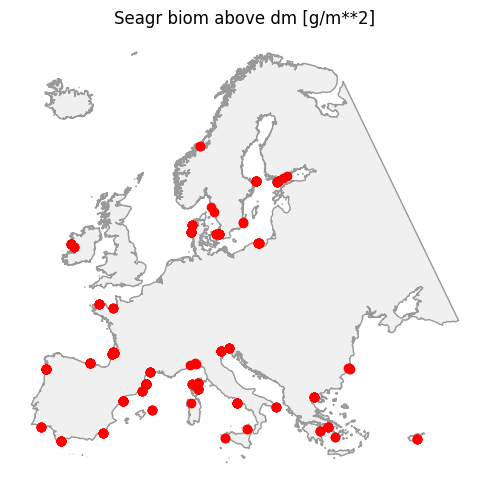

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
europe_boundary = gpd.read_file("../../data/processed/spatial_data/europe_boundary.gpkg")
seagrass_data = gpd.read_file("../../data/processed/spatial_data/seagrass/seagrass_biomass_europe.gpkg").to_crs(europe_boundary.crs)
print(seagrass_data.columns.tolist())
column_name = 'Seagr biom above dm [g/m**2]'
seagrass_data_filtered = seagrass_data[seagrass_data[column_name].notna()]

fig, ax = plt.subplots(figsize=(5,5))
europe_boundary.plot(ax=ax, color="#f0f0f0", edgecolor="#999999")
seagrass_data_filtered.plot(ax=ax, color='red')
ax.set_title(f"{column_name}")
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### Spatial interpolation of biomass density (gDW/m2) data

In [18]:
import numpy as np
import geopandas as gpd
import rasterio
from scipy.interpolate import RBFInterpolator

# load data
seagrass_data = gpd.read_file("../../data/processed/spatial_data/seagrass/seagrass_biomass_europe.gpkg")

# load base raster to get grid definition
with rasterio.open("../../data/processed/spatial_data/europe_boundary_10km.tif") as src:
    base_transform = src.transform
    base_crs = src.crs
    base_shape = src.shape
    print(f"Base raster shape: {base_shape}, CRS: {base_crs}")

# reproject points to match base raster CRS
if seagrass_data.crs != base_crs:
    print(f"Reprojecting from {seagrass_data.crs} to {base_crs}...")
    seagrass_data = seagrass_data.to_crs(base_crs)

# drop NaNs in biomass column
col = 'Seagr biom above dm [g/m**2]'
seagrass_clean = seagrass_data[seagrass_data[col].notna()].copy()
print(f"Using {len(seagrass_clean)} points with valid biomass values")

# extract coordinates and values
coords = np.column_stack([
    seagrass_clean.geometry.x,
    seagrass_clean.geometry.y
])
values = seagrass_clean[col].values

# normalize coordinates to improve numerical stability
# RBF works better when coordinates are not in the millions
coord_mean = coords.mean(axis=0)
coord_std = coords.std(axis=0)
coords_norm = (coords - coord_mean) / coord_std

# build RBF interpolator
print("Building RBF interpolator...")
rbf = RBFInterpolator(
    coords_norm,
    values,
    kernel='thin_plate_spline',  # smooth, no free parameters needed
    smoothing=1.0                 # small smoothing to avoid overfitting noisy data
)

# build grid of pixel center coordinates matching the base raster
rows, cols = np.meshgrid(
    np.arange(base_shape[0]),
    np.arange(base_shape[1]),
    indexing='ij'
)

# convert pixel indices to coordinates using the raster transform
xs = base_transform.c + (cols + 0.5) * base_transform.a
ys = base_transform.f + (rows + 0.5) * base_transform.e

# normalize grid coordinates the same way as training points
grid_coords = np.column_stack([xs.ravel(), ys.ravel()])
grid_coords_norm = (grid_coords - coord_mean) / coord_std

# interpolate — this is the slow step for large rasters
print(f"Interpolating over {grid_coords.shape[0]:,} pixels...")
biomass_grid = rbf(grid_coords_norm).reshape(base_shape)

# clip negative values (RBF can extrapolate below zero in sparse areas)
biomass_grid = np.clip(biomass_grid, 0, None)

print(f"Interpolated biomass stats:")
print(f"  min:  {biomass_grid.min():.2f} g/m²")
print(f"  mean: {biomass_grid.mean():.2f} g/m²")
print(f"  max:  {biomass_grid.max():.2f} g/m²")

# save as geotiff
output_path = "../../data/processed/spatial_data/seagrass/seagrass_biomass_density_10km.tif"
with rasterio.open(
    output_path, 'w',
    driver='GTiff',
    height=base_shape[0],
    width=base_shape[1],
    count=1,
    dtype=np.float32,
    crs=base_crs,
    transform=base_transform,
    nodata=-9999
) as dst:
    dst.write(biomass_grid.astype(np.float32), 1)

print(f"Saved to {output_path}")

Base raster shape: (404, 421), CRS: EPSG:3035
Using 532 points with valid biomass values
Building RBF interpolator...
Interpolating over 170,084 pixels...
Interpolated biomass stats:
  min:  0.00 g/m²
  mean: 87.14 g/m²
  max:  654.80 g/m²
Saved to ../../data/processed/spatial_data/seagrass/seagrass_biomass_density_10km.tif


#### Visualize seagrass biomass density raster

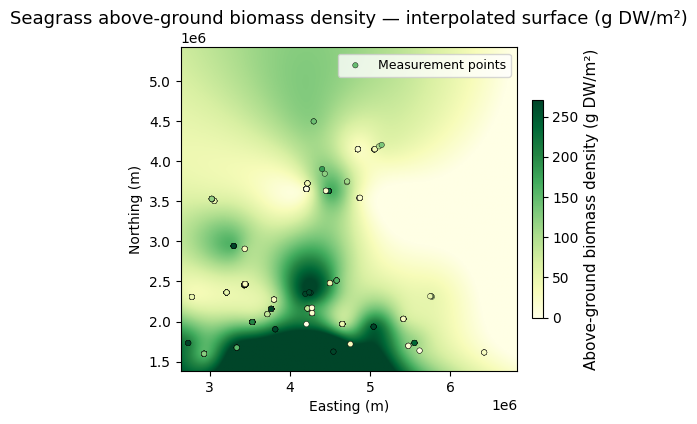

In [20]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
import numpy as np

with rasterio.open("../../data/processed/spatial_data/seagrass/seagrass_biomass_density_10km.tif") as src:
    biomass = src.read(1).astype(float)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

# mask nodata
biomass[biomass == -9999] = np.nan

fig, ax = plt.subplots(figsize=(5,5))

im = ax.imshow(
    biomass,
    extent=extent,
    origin='upper',
    cmap='YlGn',
    vmin=0,
    vmax=np.nanpercentile(biomass, 95)  # cap at 95th percentile so outliers don't squash the colormap
)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Above-ground biomass density (g DW/m²)', fontsize=11)

# overlay the original data points for reference
ax.scatter(
    seagrass_clean.geometry.x,
    seagrass_clean.geometry.y,
    c=seagrass_clean[col],
    cmap='YlGn',
    vmin=0,
    vmax=np.nanpercentile(biomass, 95),
    s=15,
    edgecolors='black',
    linewidths=0.3,
    zorder=5,
    label='Measurement points'
)

ax.legend(fontsize=9)
ax.set_title('Seagrass above-ground biomass density — interpolated surface (g DW/m²)', fontsize=13)
ax.set_xlabel('Easting (m)', fontsize=10)
ax.set_ylabel('Northing (m)', fontsize=10)

plt.tight_layout()
plt.show()

### Beaches

#### Filter beach data

See link: https://zenodo.org/records/15607678

In [3]:
import geopandas as gpd

coastal = gpd.read_parquet("../../data/raw_data/spatial_data/seagrass/Europe_beaches.parquet")

# Basic checks
print(f"Number of features: {len(coastal)}")
print(f"CRS: {coastal.crs}")
print(f"\nColumns: {coastal.columns.tolist()}")
print(f"\nGeometry types: {coastal.geometry.geom_type.value_counts()}")

# Filter relevant data and save as GeoPackage
beaches = coastal[(coastal['class:coastal_type'] == 'sediment_plain') & (coastal['class:shore_type'] == 'sandy_gravel_or_small_boulder_sediments')]
beaches.to_file("../../data/processed/spatial_data/seagrass/beaches_europe.gpkg", driver="GPKG")

Number of features: 1778828
CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": 

#### Rasterize
- Added a 10km buffer to the beach data, so that the beach mask can be fuzzier and catch more seagrass 

In [14]:
import numpy as np
import rasterio
from rasterio.features import rasterize
import geopandas as gpd

# load base raster to get grid definition
with rasterio.open("../../data/processed/spatial_data/europe_boundary_10km.tif") as src:
    base_transform = src.transform
    base_crs = src.crs
    base_shape = src.shape

print(f"Base raster shape: {base_shape}, CRS: {base_crs}")

# load beaches
beaches = gpd.read_file("../../data/processed/spatial_data/seagrass/beaches_europe.gpkg")
print(f"Loaded {len(beaches)} beach features in CRS: {beaches.crs}")

# reproject if needed
if beaches.crs != base_crs:
    print(f"Reprojecting beaches to {base_crs}...")
    beaches = beaches.to_crs(base_crs)

# add buffer
beaches['geometry'] = beaches.geometry.buffer(10_000)  # 10km buffer to ensure we capture the beach area in the rasterization

# rasterize as binary mask (1 = beach present, 0 = no beach)
beach_mask = rasterize(
    [(geom, 1) for geom in beaches.geometry if geom is not None and not geom.is_empty],
    out_shape=base_shape,
    transform=base_transform,
    fill=0,
    dtype=np.uint8
)

print(f"Pixels with beach: {(beach_mask > 0).sum()}")

# save
output_path = "../../data/processed/spatial_data/seagrass/beaches_mask_10km.tif"
with rasterio.open(
    output_path, 'w',
    driver='GTiff',
    height=base_shape[0],
    width=base_shape[1],
    count=1,
    dtype=np.uint8,
    crs=base_crs,
    transform=base_transform,
    nodata=255
) as dst:
    dst.write(beach_mask, 1)

print(f"Saved to {output_path}")

Base raster shape: (404, 421), CRS: EPSG:3035
Loaded 255748 beach features in CRS: EPSG:4326
Reprojecting beaches to EPSG:3035...
Pixels with beach: 9073
Saved to ../../data/processed/spatial_data/seagrass/beaches_mask_10km.tif


#### Visualize beaches raster

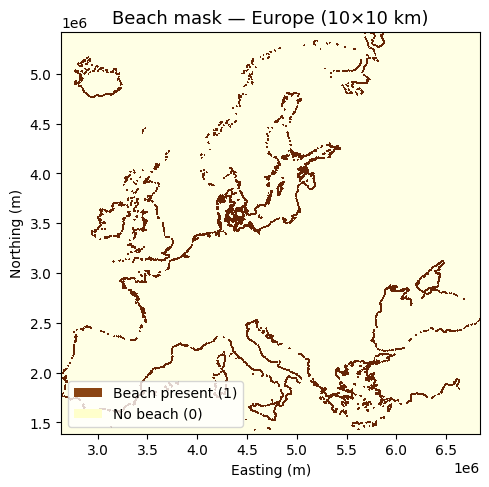

Pixels with beach: 9073
Total beach pixels area: 907300 km²


In [15]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

with rasterio.open("../../data/processed/spatial_data/seagrass/beaches_mask_10km.tif") as src:
    beach_mask = src.read(1).astype(float)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

# mask nodata
beach_mask[beach_mask == 255] = np.nan

fig, ax = plt.subplots(figsize=(5,5))

ax.imshow(
    beach_mask,
    extent=extent,
    origin='upper',
    cmap='YlOrBr',
    vmin=0,
    vmax=1,
    interpolation='nearest'  # keep binary mask crisp, no blurring between 0 and 1
)

# custom legend instead of colorbar since it's binary
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#8B4513', label='Beach present (1)'),
    Patch(facecolor='#ffffcc', label='No beach (0)')
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=10)

ax.set_title('Beach mask — Europe (10×10 km)', fontsize=13)
ax.set_xlabel('Easting (m)', fontsize=10)
ax.set_ylabel('Northing (m)', fontsize=10)

plt.tight_layout()
plt.show()

# quick summary
n_beach = int(np.nansum(beach_mask))
print(f"Pixels with beach: {n_beach}")
print(f"Total beach pixels area: {n_beach * 100:.0f} km²")

### Make seagrass yield map (10x10km resolution)

Data used: 
- area of seagrass meadow (m2) per pixel: `../../data/processed/spatial_data/seagrass/seagrass_meadow_area_m2_10km.tif`
- biomass density (gDW/m2) per pixel: `../../data/processed/spatial_data/seagrass/seagrass_biomass_density_10km.tif`
- beaches mask: `../../data/processed/spatial_data/seagrass/beaches_mask_10km.tif`

Estimation steps: 
- biomass (gDW) = meadow area (m2) x density (gDW/m2) 
- annual exported biomass (gDW/yr) = biomass (gDW) x turnover rate (2.6%/day, Duarte & Chiscano 1999) x export fraction (50% - 0.28–0.50 Zostera, 0.40–0.65 Posidonia) x 365
- annual deposited biomass on beaches (gDW/yr) = annual exported biomass (gDW) x beach mask x desposition fraction (assumed, range 0.2-0.6)

Sources (to look up): 
- biomass turnover rate: Duarte & Chiscano 1999
- export fraction: 0.28–0.50 Zostera, 0.40–0.65 Posidonia

In [19]:
import numpy as np
import rasterio

# --- load rasters ---
with rasterio.open("../../data/processed/spatial_data/seagrass/seagrass_meadow_area_m2_10km.tif") as src:
    meadow_area = src.read(1).astype(float)
    base_transform = src.transform
    base_crs = src.crs
    base_shape = src.shape
    nodata_area = src.nodata

with rasterio.open("../../data/processed/spatial_data/seagrass/seagrass_biomass_density_10km.tif") as src:
    biomass_density = src.read(1).astype(float)
    nodata_density = src.nodata

with rasterio.open("../../data/processed/spatial_data/seagrass/beaches_mask_10km.tif") as src:
    beach_mask = src.read(1).astype(float)
    nodata_beach = src.nodata

# --- mask nodata ---
meadow_area = np.where(meadow_area == nodata_area, np.nan, meadow_area)
biomass_density = np.where(biomass_density == nodata_density, np.nan, biomass_density)
beach_mask = np.where(beach_mask == 255, np.nan, beach_mask)

# --- parameters ---
turnover_annual = 0.026 * 365
export_fraction = 0.50
deposition_fraction = 0.40

# --- calculation ---
deposited_tonnes = (
    meadow_area        # m²
    * biomass_density  # g/m²
    * turnover_annual  # /yr
    * export_fraction
    * beach_mask
    * deposition_fraction
    / 1e6              # g → tonnes
)

print(f"Annual beach deposition: {np.nansum(deposited_tonnes):.1f} tonnes DW/yr")
print(f"Pixels with deposition > 0: {(deposited_tonnes > 0).sum()}")

# --- save ---
output_path = "../../data/processed/yield_maps/yield_tonnes_perYear_10km_seagrass.tif"
with rasterio.open(
    output_path, 'w',
    driver='GTiff',
    height=base_shape[0],
    width=base_shape[1],
    count=1,
    dtype=np.float32,
    crs=base_crs,
    transform=base_transform,
    nodata=-9999
) as dst:
    dst.write(np.where(np.isnan(deposited_tonnes), -9999, deposited_tonnes).astype(np.float32), 1)

print(f"Saved to {output_path}")

Annual beach deposition: 56657.5 tonnes DW/yr
Pixels with deposition > 0: 42
Saved to ../../data/processed/yield_maps/yield_tonnes_perYear_10km_seagrass.tif


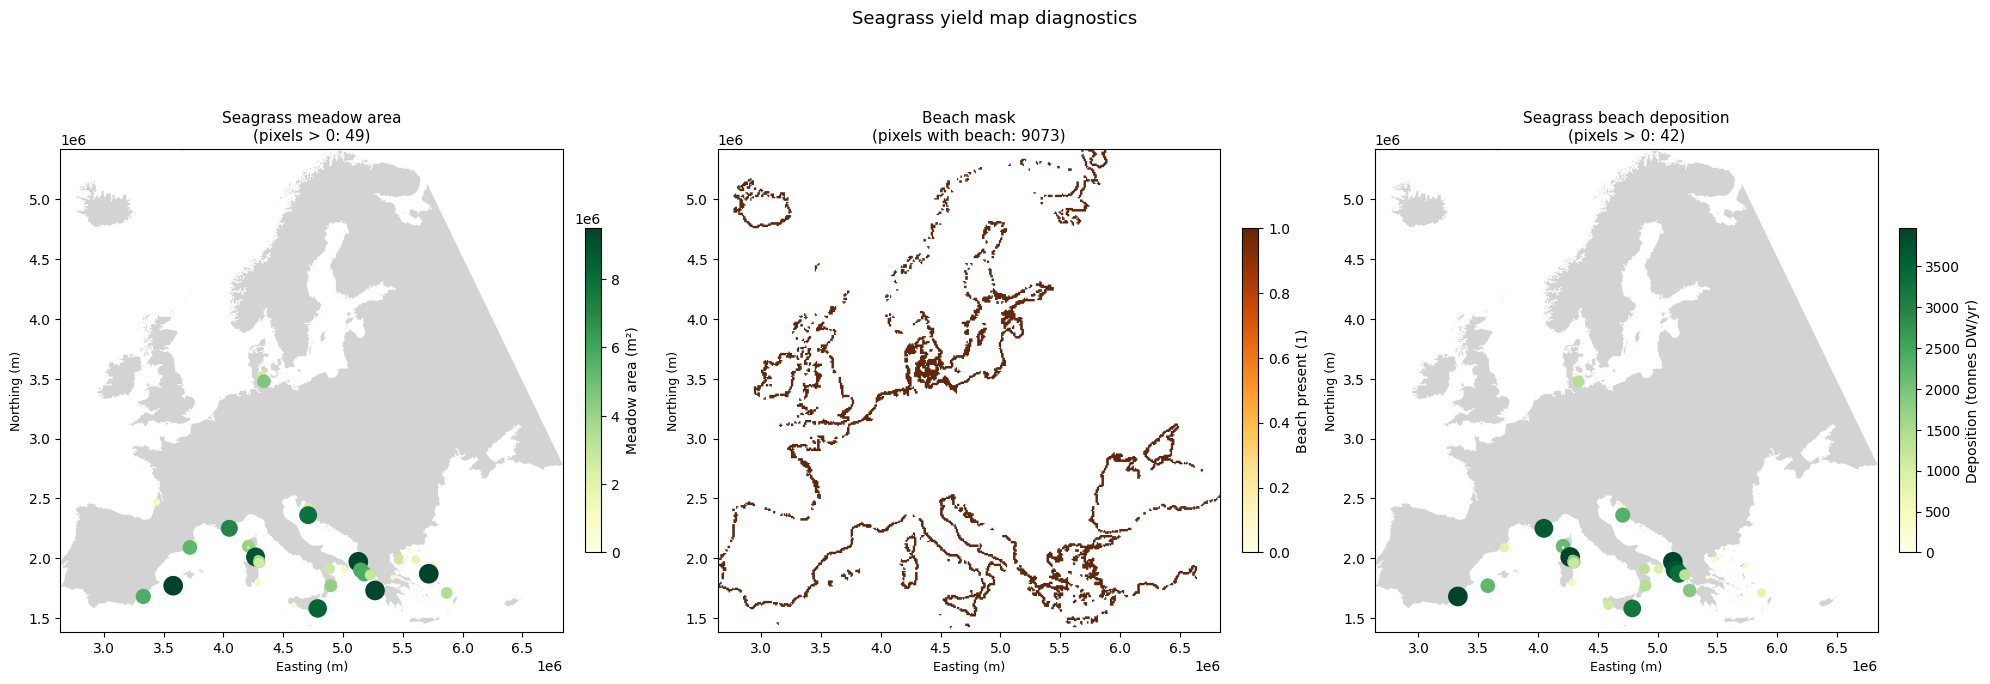

--- Overlap diagnostic ---
Pixels with seagrass:            49
Pixels with beach:               9073
Pixels with BOTH (overlap):      42
Pixels in final yield map > 0:   42


In [17]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np
import geopandas as gpd
from rasterio.transform import xy

# --- load all three rasters ---
with rasterio.open("../../data/processed/spatial_data/seagrass/seagrass_meadow_area_m2_10km.tif") as src:
    meadow_area = src.read(1).astype(float)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    nodata = src.nodata
    transform = src.transform
meadow_area[meadow_area == nodata] = np.nan
meadow_area_masked = np.where(meadow_area == 0, np.nan, meadow_area)

with rasterio.open("../../data/processed/spatial_data/seagrass/beaches_mask_10km.tif") as src:
    beach_mask = src.read(1).astype(float)
beach_mask[beach_mask == 255] = np.nan
beach_mask_masked = np.where(beach_mask == 0, np.nan, beach_mask)

with rasterio.open("../../data/processed/yield_maps/seagrass_tonnesPerYear.tif") as src:
    deposited = src.read(1).astype(float)
deposited[deposited == -9999] = np.nan
deposited_masked = np.where(deposited == 0, np.nan, deposited)

# --- load Europe boundary (reproject to match raster CRS: EPSG:3035) ---
europe = gpd.read_file("../../data/processed/spatial_data/europe_boundary.gpkg")
if europe.crs.to_epsg() != 3035:
    europe = europe.to_crs(epsg=3035)

# --- helper: raster -> scatter coords + sizes ---
def raster_to_scatter(data_masked, transform, max_size=200):
    rows, cols = np.where(~np.isnan(data_masked))
    xs, ys = xy(transform, rows, cols)
    values = data_masked[rows, cols]
    vmax = np.nanpercentile(values, 95)
    sizes = (values / vmax).clip(0, 1) * max_size
    return np.array(xs), np.array(ys), values, sizes, vmax

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# seagrass meadow area — scatter
xs, ys, vals, sizes, vmax0 = raster_to_scatter(meadow_area_masked, transform)
europe.plot(ax=axes[0], color='lightgrey', edgecolor='white', linewidth=0.3)
sc0 = axes[0].scatter(xs, ys, s=sizes, c=vals, cmap='YlGn', vmin=0, vmax=vmax0, linewidths=0)
plt.colorbar(sc0, ax=axes[0], fraction=0.03, pad=0.04, label='Meadow area (m²)')
axes[0].set_xlim(extent[0], extent[1])
axes[0].set_ylim(extent[2], extent[3])
axes[0].set_title(f'Seagrass meadow area\n(pixels > 0: {(meadow_area > 0).sum()})', fontsize=11)

# beach mask — imshow (binary, stays as raster)
im1 = axes[1].imshow(
    beach_mask_masked,
    extent=extent, origin='upper',
    cmap='YlOrBr',
    vmin=0, vmax=1
)
plt.colorbar(im1, ax=axes[1], fraction=0.03, pad=0.04, label='Beach present (1)')
axes[1].set_title(f'Beach mask\n(pixels with beach: {int(np.nansum(beach_mask))})', fontsize=11)

# beach deposition — scatter
xs2, ys2, vals2, sizes2, vmax2 = raster_to_scatter(deposited_masked, transform)
europe.plot(ax=axes[2], color='lightgrey', edgecolor='white', linewidth=0.3)
sc2 = axes[2].scatter(xs2, ys2, s=sizes2, c=vals2, cmap='YlGn', vmin=0, vmax=vmax2, linewidths=0)
plt.colorbar(sc2, ax=axes[2], fraction=0.03, pad=0.04, label='Deposition (tonnes DW/yr)')
axes[2].set_xlim(extent[0], extent[1])
axes[2].set_ylim(extent[2], extent[3])
axes[2].set_title(f'Seagrass beach deposition\n(pixels > 0: {(deposited > 0).sum()})', fontsize=11)

for ax in axes:
    ax.set_xlabel('Easting (m)', fontsize=9)
    ax.set_ylabel('Northing (m)', fontsize=9)

plt.suptitle('Seagrass yield map diagnostics', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- diagnostic print ---
print("--- Overlap diagnostic ---")
seagrass_pixels = meadow_area > 0
beach_pixels = beach_mask == 1
overlap = seagrass_pixels & beach_pixels
print(f"Pixels with seagrass:            {seagrass_pixels.sum()}")
print(f"Pixels with beach:               {beach_pixels.sum()}")
print(f"Pixels with BOTH (overlap):      {overlap.sum()}")
print(f"Pixels in final yield map > 0:   {(deposited > 0).sum()}")

## Climate data 

### Average temperature

In [44]:
import rasterio
import numpy as np
import os

data_dir = "../../data/raw_data/spatial_data/climate/wc2.1_10m_tavg"

files = sorted([f for f in os.listdir(data_dir) if f.endswith(".tif")])

print(f"{'File':<35} {'Min':>8} {'Max':>8} {'Mean':>8} {'NoData cells':>15}")
print("-" * 75)

for fname in files:
    fpath = os.path.join(data_dir, fname)
    with rasterio.open(fpath) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        
        # Mask out nodata values
        if nodata is not None:
            data = np.where(data == nodata, np.nan, data)
        else:
            # WorldClim uses -32768 as nodata if not explicitly set
            data = np.where(data < -100, np.nan, data)
        
        valid = data[~np.isnan(data)]
        print(f"{fname:<35} {valid.min():>8.1f} {valid.max():>8.1f} {valid.mean():>8.1f} {np.isnan(data).sum():>15,}")

File                                     Min      Max     Mean    NoData cells
---------------------------------------------------------------------------
wc2.1_10m_tavg_01.tif                  -45.9     34.0     -6.7       1,524,747
wc2.1_10m_tavg_02.tif                  -44.8     32.8     -8.0       1,524,747
wc2.1_10m_tavg_03.tif                  -57.9     32.9     -8.2       1,524,747
wc2.1_10m_tavg_04.tif                  -64.2     34.2     -6.0       1,524,747
wc2.1_10m_tavg_05.tif                  -64.8     36.3     -3.1       1,524,747
wc2.1_10m_tavg_06.tif                  -64.4     38.4     -0.3       1,524,747
wc2.1_10m_tavg_07.tif                  -68.5     39.5      0.5       1,524,747
wc2.1_10m_tavg_08.tif                  -66.5     38.4     -0.3       1,524,747
wc2.1_10m_tavg_09.tif                  -64.6     35.8     -1.9       1,524,747
wc2.1_10m_tavg_10.tif                  -55.9     32.7     -3.8       1,524,747
wc2.1_10m_tavg_11.tif                  -43.4     32.8  

In [45]:
import rasterio
import rasterio.mask
import geopandas as gpd
import os

# Paths
input_dir = "../../data/raw_data/spatial_data/climate/wc2.1_10m_tavg"
boundary_path = "../../data/processed/spatial_data/europe_boundary.gpkg"
output_dir = "../../data/processed/spatial_data/climate"

os.makedirs(output_dir, exist_ok=True)

# Load European boundary
europe = gpd.read_file(boundary_path)

# Get list of tif files
files = sorted([f for f in os.listdir(input_dir) if f.endswith(".tif")])

for fname in files:
    input_path = os.path.join(input_dir, fname)
    output_path = os.path.join(output_dir, fname)  # keeps original filename

    with rasterio.open(input_path) as src:
        # Reproject boundary to match raster CRS if needed
        if europe.crs != src.crs:
            europe_reprojected = europe.to_crs(src.crs)
        else:
            europe_reprojected = europe

        # Crop to boundary
        cropped_data, cropped_transform = rasterio.mask.mask(
            src,
            europe_reprojected.geometry,
            crop=True,
            nodata=-32768
        )

        # Update metadata
        out_profile = src.profile.copy()
        out_profile.update({
            "height": cropped_data.shape[1],
            "width": cropped_data.shape[2],
            "transform": cropped_transform,
            "nodata": -32768
        })

        with rasterio.open(output_path, "w", **out_profile) as dst:
            dst.write(cropped_data)

    print(f"Saved: {fname}")

print("Done — all 12 months cropped to Europe.")

Saved: wc2.1_10m_tavg_01.tif
Saved: wc2.1_10m_tavg_02.tif
Saved: wc2.1_10m_tavg_03.tif
Saved: wc2.1_10m_tavg_04.tif
Saved: wc2.1_10m_tavg_05.tif
Saved: wc2.1_10m_tavg_06.tif
Saved: wc2.1_10m_tavg_07.tif
Saved: wc2.1_10m_tavg_08.tif
Saved: wc2.1_10m_tavg_09.tif
Saved: wc2.1_10m_tavg_10.tif
Saved: wc2.1_10m_tavg_11.tif
Saved: wc2.1_10m_tavg_12.tif
Done — all 12 months cropped to Europe.


### Water vapour pressure (kPa)

In [46]:
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
import os

# Paths
input_dir = "../../data/raw_data/spatial_data/climate/wc2.1_10m_vapr"
boundary_path = "../../data/processed/spatial_data/europe_boundary.gpkg"
output_dir = "../../data/processed/spatial_data/climate"

os.makedirs(output_dir, exist_ok=True)

# Load European boundary
europe = gpd.read_file(boundary_path)

# Get list of tif files
files = sorted([f for f in os.listdir(input_dir) if f.endswith(".tif")])

# --- Step 1: Check data quality ---
print("Data quality check:")
print(f"{'File':<35} {'Min':>8} {'Max':>8} {'Mean':>8} {'NoData cells':>15}")
print("-" * 75)

for fname in files:
    fpath = os.path.join(input_dir, fname)
    with rasterio.open(fpath) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            data = np.where(data == nodata, np.nan, data)
        else:
            data = np.where(data < -100, np.nan, data)

        valid = data[~np.isnan(data)]
        print(f"{fname:<35} {valid.min():>8.4f} {valid.max():>8.4f} {valid.mean():>8.4f} {np.isnan(data).sum():>15,}")

# --- Step 2: Crop to Europe and save ---
print("\nCropping to Europe:")

for fname in files:
    input_path = os.path.join(input_dir, fname)
    output_path = os.path.join(output_dir, fname)

    with rasterio.open(input_path) as src:
        if europe.crs != src.crs:
            europe_reprojected = europe.to_crs(src.crs)
        else:
            europe_reprojected = europe

        cropped_data, cropped_transform = rasterio.mask.mask(
            src,
            europe_reprojected.geometry,
            crop=True,
            nodata=-32768
        )

        out_profile = src.profile.copy()
        out_profile.update({
            "height": cropped_data.shape[1],
            "width": cropped_data.shape[2],
            "transform": cropped_transform,
            "nodata": -32768
        })

        with rasterio.open(output_path, "w", **out_profile) as dst:
            dst.write(cropped_data)

    print(f"Saved: {fname}")

print("\nDone — all 12 months checked and cropped to Europe.")

Data quality check:
File                                     Min      Max     Mean    NoData cells
---------------------------------------------------------------------------
wc2.1_10m_vapr_01.tif                 0.0000   3.3000   0.6033       1,524,747
wc2.1_10m_vapr_02.tif                 0.0000   3.2180   0.6027       1,524,747
wc2.1_10m_vapr_03.tif                 0.0000   3.2600   0.6305       1,524,747
wc2.1_10m_vapr_04.tif                 0.0000   3.3400   0.6911       1,524,747
wc2.1_10m_vapr_05.tif                 0.0000   3.4304   0.7847       1,524,747
wc2.1_10m_vapr_06.tif                 0.0000   3.4666   0.9146       1,524,747
wc2.1_10m_vapr_07.tif                 0.0000   3.5636   1.0231       1,524,747
wc2.1_10m_vapr_08.tif                 0.0000   3.5221   1.0009       1,524,747
wc2.1_10m_vapr_09.tif                 0.0000   3.5200   0.8752       1,524,747
wc2.1_10m_vapr_10.tif                 0.0000   3.2900   0.7390       1,524,747
wc2.1_10m_vapr_11.tif              

In [48]:
import rasterio
import rasterio.mask
import numpy as np
import os

# Paths
vapr_dir = "../../data/processed/spatial_data/climate"
tavg_dir = "../../data/processed/spatial_data/climate"
output_dir = "../../data/processed/spatial_data/climate"

os.makedirs(output_dir, exist_ok=True)

def saturation_vapour_pressure(temp_celsius):
    """Calculate saturation vapour pressure using the Magnus formula (kPa)."""
    return 0.6108 * np.exp(17.27 * temp_celsius / (temp_celsius + 237.3))

def load_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        profile = src.profile.copy()
        nodata = src.nodata
        if nodata is not None:
            data = np.where(data == nodata, np.nan, data)
        else:
            data = np.where(data < -100, np.nan, data)
    return data, profile

print(f"{'File':<40} {'Min RH':>10} {'Max RH':>10} {'Mean RH':>10}")
print("-" * 75)

for month in range(1, 13):
    month_str = f"{month:02d}"

    vapr_path = os.path.join(vapr_dir, f"wc2.1_10m_vapr_{month_str}.tif")
    tavg_path = os.path.join(tavg_dir, f"wc2.1_10m_tavg_{month_str}.tif")
    output_path = os.path.join(output_dir, f"wc2.1_10m_rh_{month_str}.tif")

    # Load both rasters
    vapr, vapr_profile = load_raster(vapr_path)
    tavg, _ = load_raster(tavg_path)

    # Calculate relative humidity
    e_s = saturation_vapour_pressure(tavg)
    rh = (vapr / e_s) * 100

    # Clamp to physically valid range (0–100%)
    rh = np.clip(rh, 0, 100)

    # Restore nodata mask
    nodata_mask = np.isnan(vapr) | np.isnan(tavg)
    rh[nodata_mask] = -32768

    # Save output
    out_profile = vapr_profile.copy()
    out_profile.update({
        "dtype": "float32",
        "nodata": -32768
    })

    with rasterio.open(output_path, "w", **out_profile) as dst:
        dst.write(rh.astype("float32"), 1)

    # Print quality check (valid cells only)
    valid_rh = rh[rh != -32768]
    print(f"wc2.1_10m_rh_{month_str}.tif {valid_rh.min():>10.1f} {valid_rh.max():>10.1f} {valid_rh.mean():>10.1f}")

print("\nDone — relative humidity saved for all 12 months.")

File                                         Min RH     Max RH    Mean RH
---------------------------------------------------------------------------
wc2.1_10m_rh_01.tif       40.8      100.0       83.7
wc2.1_10m_rh_02.tif       48.0      100.0       81.4
wc2.1_10m_rh_03.tif       55.9      100.0       76.6
wc2.1_10m_rh_04.tif       54.4       95.8       71.0
wc2.1_10m_rh_05.tif       48.1       95.5       68.0
wc2.1_10m_rh_06.tif       42.3      100.0       69.1
wc2.1_10m_rh_07.tif       39.1      100.0       70.3
wc2.1_10m_rh_08.tif       41.8      100.0       72.0
wc2.1_10m_rh_09.tif       45.4      100.0       76.2
wc2.1_10m_rh_10.tif       48.0       96.8       80.1
wc2.1_10m_rh_11.tif       55.4      100.0       84.7
wc2.1_10m_rh_12.tif       41.1      100.0       84.7

Done — relative humidity saved for all 12 months.


### Aggregate to Europe raster

In [38]:
"""
Aggregate WorldClim monthly climate data to the Europe 10km reference grid.

Extracts January (coldest) and July (hottest) for:
  - Average temperature (°C)
  - Relative humidity (%)

Reprojects and resamples both to match europe_boundary_10km.tif exactly.

Outputs:
  europe_10km_temperature_degC_Jan_Jul.tif   (band 1 = Jan, band 2 = Jul)
  europe_10km_relative_humidity_pct_Jan_Jul.tif  (band 1 = Jan, band 2 = Jul)
"""

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

# ── Config ────────────────────────────────────────────────────────────────────

CLIMATE_DIR = "../../data/processed/spatial_data/climate"
OUT_DIR     = "../../data/processed/spatial_data/climate"
REF_PATH    = "../../data/processed/spatial_data/europe_boundary_10km.tif"

MONTHS = {"Jan": "01", "Jul": "07"}

VARIABLES = {
    "temperature_degC":    "wc2.1_10m_tavg",
    "relative_humidity_pct": "wc2.1_10m_rh",
}

# ── Load reference grid ───────────────────────────────────────────────────────

print("Loading reference grid …")
with rasterio.open(REF_PATH) as ref:
    ref_crs       = ref.crs
    ref_transform = ref.transform
    ref_width     = ref.width
    ref_height    = ref.height

print(f"  CRS: {ref_crs}")
print(f"  Size: {ref_width} × {ref_height} px\n")

# ── Process each variable ─────────────────────────────────────────────────────

for var_name, file_prefix in VARIABLES.items():
    out_path = f"{OUT_DIR}/europe_10km_{var_name}_Jan_Jul.tif"
    print(f"── {var_name} ──────────────────────────────────────────")

    bands = []

    for month_name, month_num in MONTHS.items():
        src_path = f"{CLIMATE_DIR}/{file_prefix}_{month_num}.tif"
        print(f"  Reading {month_name} ({src_path.split('/')[-1]}) …")

        with rasterio.open(src_path) as src:
            data      = src.read(1).astype(np.float32)
            src_crs   = src.crs
            src_trans = src.transform
            nodata    = src.nodata

        if nodata is not None:
            data = np.where(data == nodata, np.nan, data)

        # Reproject to reference grid using bilinear resampling (appropriate
        # for continuous variables like temperature and humidity)
        dst_data = np.full((ref_height, ref_width), np.nan, dtype=np.float32)

        reproject(
            source        = data,
            destination   = dst_data,
            src_transform = src_trans,
            src_crs       = src_crs,
            src_nodata    = np.nan,
            dst_transform = ref_transform,
            dst_crs       = ref_crs,
            dst_nodata    = np.nan,
            resampling    = Resampling.bilinear,
        )

        valid = int(np.sum(~np.isnan(dst_data)))
        print(f"    mean={np.nanmean(dst_data):.2f}  min={np.nanmin(dst_data):.2f}"
              f"  max={np.nanmax(dst_data):.2f}  valid pixels={valid:,}")

        bands.append(dst_data)

    # ── Write 2-band GeoTIFF ──────────────────────────────────────────────────
    out_profile = {
        "driver":    "GTiff",
        "dtype":     "float32",
        "width":     ref_width,
        "height":    ref_height,
        "count":     2,
        "crs":       ref_crs,
        "transform": ref_transform,
        "nodata":    -9999.0,
        "compress":  "lzw",
        "tiled":     True,
        "blockxsize": 256,
        "blockysize": 256,
    }

    out_bands = [np.where(np.isnan(b), -9999.0, b).astype(np.float32) for b in bands]

    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(out_bands[0], 1)
        dst.write(out_bands[1], 2)
        dst.update_tags(
            band_1      = "January (coldest month)",
            band_2      = "July (hottest month)",
            variable    = var_name,
            source      = "WorldClim 2.1 10m",
            grid        = "Aligned to europe_boundary_10km.tif",
        )
        dst.update_tags(1, month="January", month_num="01")
        dst.update_tags(2, month="July",    month_num="07")

    print(f"  Saved → {out_path}\n")

print("Done.")

Loading reference grid …
  CRS: EPSG:3035
  Size: 421 × 404 px

── temperature_degC ──────────────────────────────────────────
  Reading Jan (wc2.1_10m_tavg_01.tif) …
    mean=-2.39  min=-16.25  max=14.10  valid pixels=82,442
  Reading Jul (wc2.1_10m_tavg_07.tif) …
    mean=17.87  min=1.01  max=28.53  valid pixels=82,442
  Saved → ../../data/processed/spatial_data/climate/europe_10km_temperature_degC_Jan_Jul.tif

── relative_humidity_pct ──────────────────────────────────────────
  Reading Jan (wc2.1_10m_rh_01.tif) …
    mean=83.22  min=44.84  max=100.00  valid pixels=82,442
  Reading Jul (wc2.1_10m_rh_07.tif) …
    mean=69.36  min=39.29  max=98.87  valid pixels=82,442
  Saved → ../../data/processed/spatial_data/climate/europe_10km_relative_humidity_pct_Jan_Jul.tif

Done.


### Plot maps

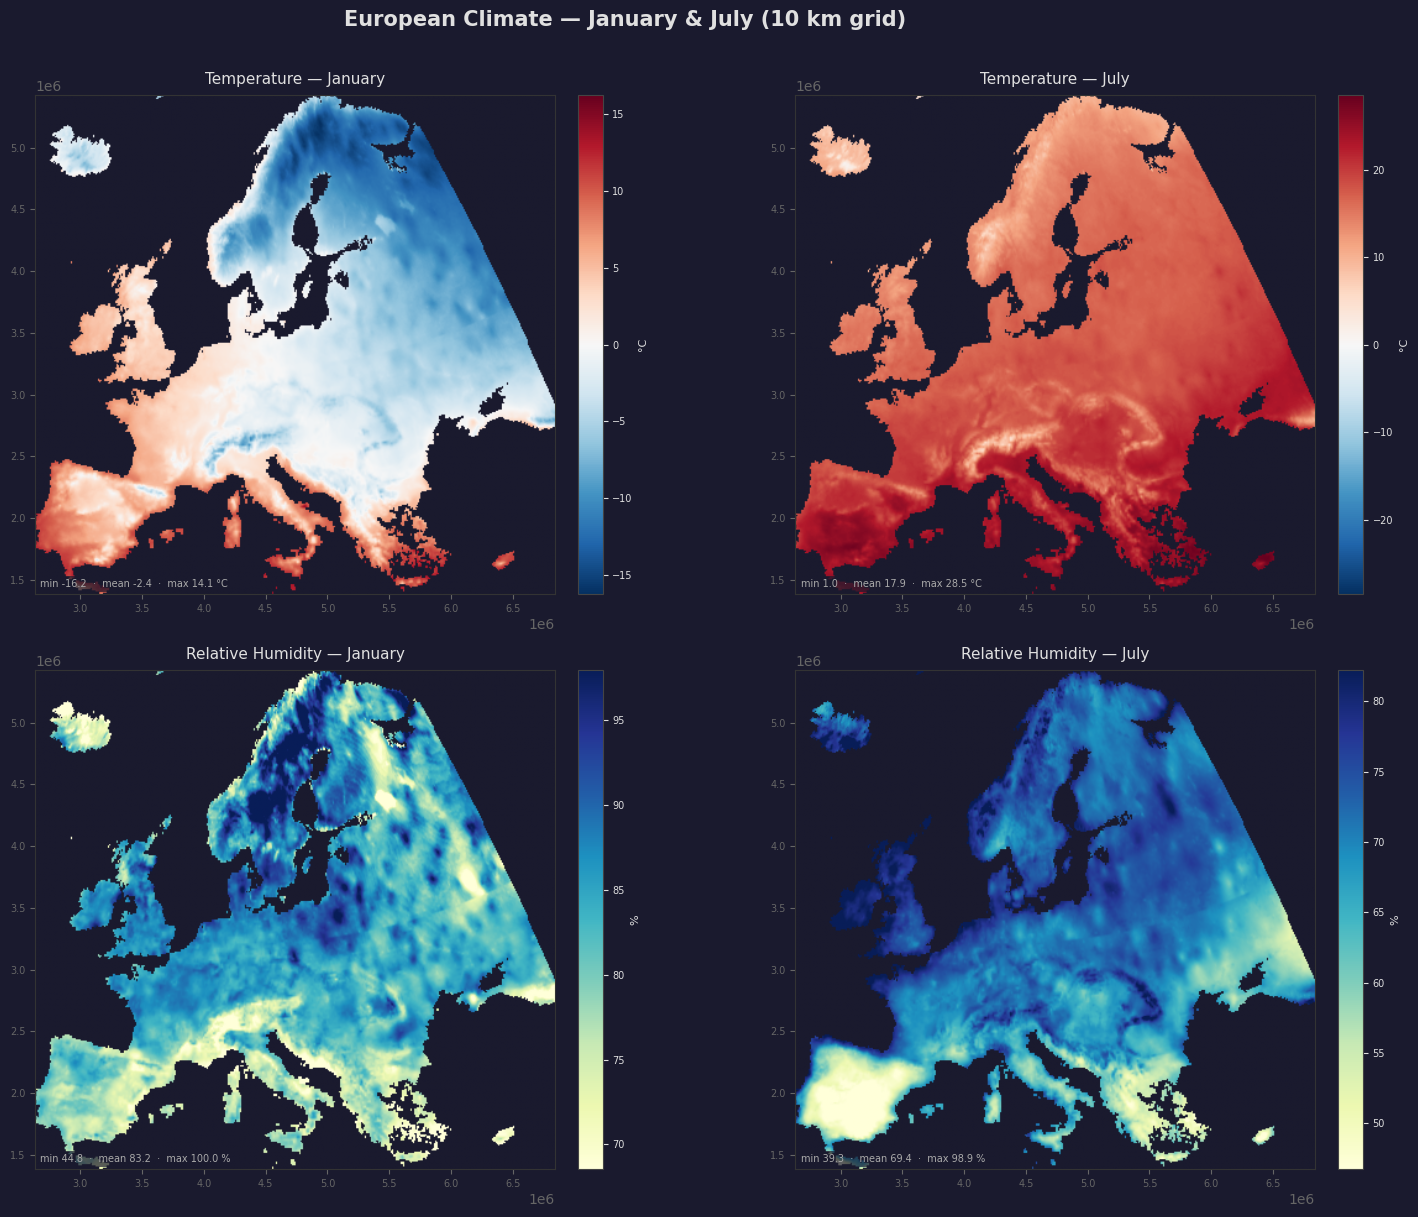

In [40]:
"""
Visualize January and July climate data: temperature and relative humidity.
Four panels in a 2x2 grid.
"""

import numpy as np
import rasterio
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────

CLIMATE_DIR = "../../data/processed/spatial_data/climate"

FILES = {
    "temp":  f"{CLIMATE_DIR}/europe_10km_temperature_degC_Jan_Jul.tif",
    "humid": f"{CLIMATE_DIR}/europe_10km_relative_humidity_pct_Jan_Jul.tif",
}

PANELS = [
    {"file": "temp",  "band": 1, "title": "Temperature — January", "cmap": "RdBu_r", "unit": "°C"},
    {"file": "temp",  "band": 2, "title": "Temperature — July",    "cmap": "RdBu_r", "unit": "°C"},
    {"file": "humid", "band": 1, "title": "Relative Humidity — January", "cmap": "YlGnBu", "unit": "%"},
    {"file": "humid", "band": 2, "title": "Relative Humidity — July",    "cmap": "YlGnBu", "unit": "%"},
]

BG_COLOR   = "#1a1a2e"
TEXT_COLOR = "#e0e0e0"

# ── Load data ─────────────────────────────────────────────────────────────────

loaded = {}
for key, path in FILES.items():
    with rasterio.open(path) as src:
        loaded[key] = {
            "bands":  [src.read(b).astype(float) for b in (1, 2)],
            "bounds": src.bounds,
            "nodata": src.nodata,
        }
    for band in loaded[key]["bands"]:
        if loaded[key]["nodata"] is not None:
            band[band == loaded[key]["nodata"]] = np.nan

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor=BG_COLOR)
fig.suptitle("European Climate — January & July (10 km grid)",
             color=TEXT_COLOR, fontsize=15, fontweight="bold", y=1.01)

for ax, panel in zip(axes.flat, PANELS):
    ds     = loaded[panel["file"]]
    data   = ds["bands"][panel["band"] - 1]
    bounds = ds["bounds"]
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    # Symmetric colour scale for temperature (so 0°C is always white/neutral)
    if panel["file"] == "temp":
        vabs = np.nanmax(np.abs(data))
        vmin, vmax = -vabs, vabs
    else:
        vmin = np.nanpercentile(data, 2)
        vmax = np.nanpercentile(data, 98)

    cmap = plt.get_cmap(panel["cmap"]).copy()
    cmap.set_bad(color=BG_COLOR)

    im = ax.imshow(
        data,
        extent=extent,
        origin="upper",
        cmap=cmap,
        interpolation="bilinear",
        vmin=vmin,
        vmax=vmax,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR, labelcolor=TEXT_COLOR, labelsize=7)
    cbar.outline.set_edgecolor("#444444")
    cbar.set_label(panel["unit"], color=TEXT_COLOR, fontsize=8)

    stats = (f"min {np.nanmin(data):.1f}  ·  "
             f"mean {np.nanmean(data):.1f}  ·  "
             f"max {np.nanmax(data):.1f} {panel['unit']}")
    ax.text(0.01, 0.01, stats, transform=ax.transAxes,
            color="#aaaaaa", fontsize=7, va="bottom",
            bbox=dict(facecolor=BG_COLOR, edgecolor="none", alpha=0.7, pad=2))

    ax.set_title(panel["title"], color=TEXT_COLOR, fontsize=11, pad=8)
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors="#666666", labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

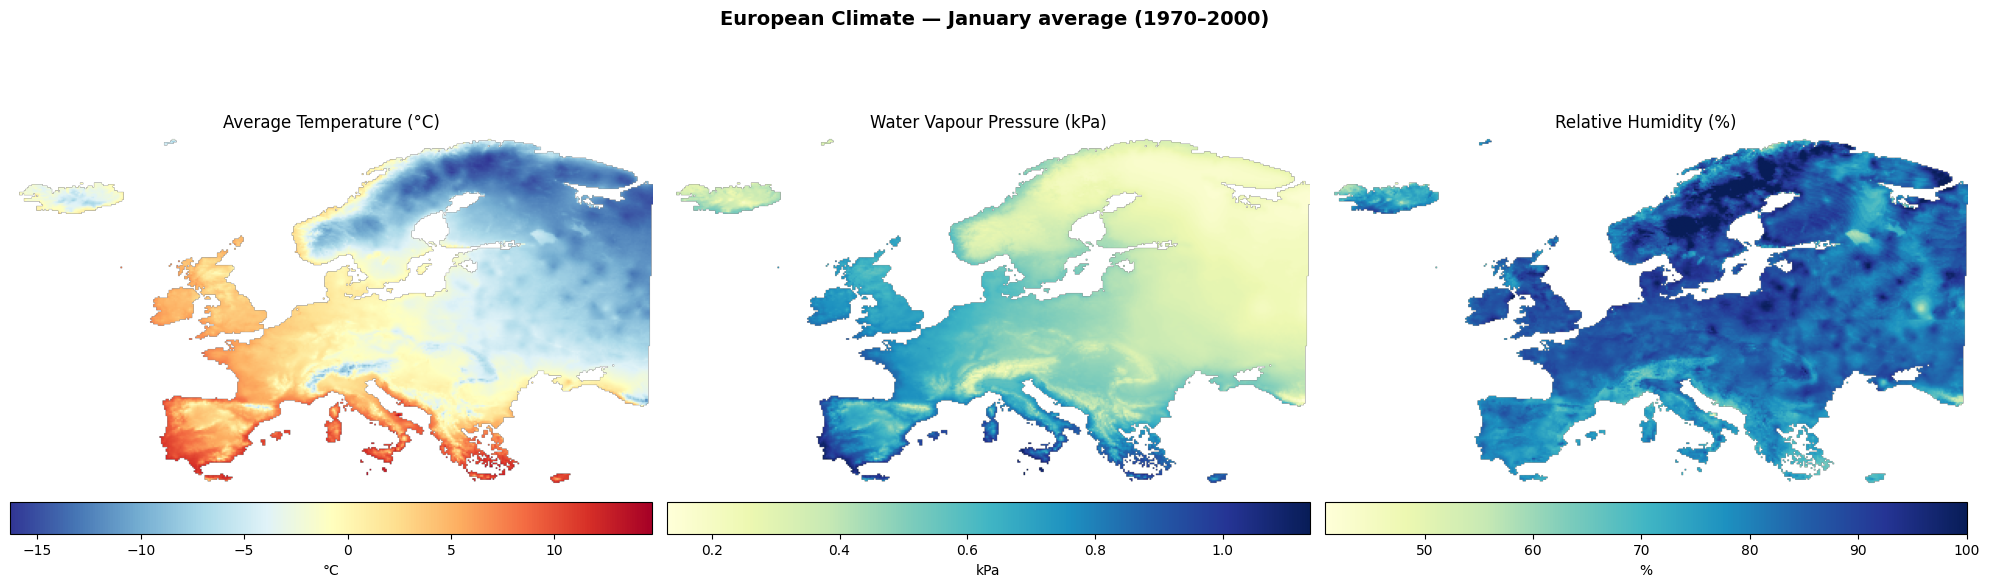

In [50]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Paths
tavg_path = "../../data/processed/spatial_data/climate/wc2.1_10m_tavg_01.tif"
vapr_path = "../../data/processed/spatial_data/climate/wc2.1_10m_vapr_01.tif"
rh_path   = "../../data/processed/spatial_data/climate/wc2.1_10m_rh_01.tif"

# Load data
def load_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        data = np.where(data < -100, np.nan, data)
    return data

tavg = load_raster(tavg_path)
vapr = load_raster(vapr_path)
rh   = load_raster(rh_path)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("European Climate — January average (1970–2000)", fontsize=14, fontweight="bold")

layers = [
    (tavg, "Average Temperature (°C)",    "RdYlBu_r", "°C"),
    (vapr, "Water Vapour Pressure (kPa)", "YlGnBu",   "kPa"),
    (rh,   "Relative Humidity (%)",       "YlGnBu",   "%"),
]

for ax, (data, title, cmap, label) in zip(axes, layers):
    # Derive vmin and vmax from actual data range
    vmin = np.nanmin(data)
    vmax = np.nanmax(data)

    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.axis("off")
    plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.03, label=label)

plt.tight_layout()
plt.show()